In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd()))

from Modules.fun_taylor import (
    calculate_expected_inflation_12m,
    friedman_seasonality_test,
    get_series_for_test,
    optimized_ljung_box_test,
    stationarity_tests,
    extract_ardl_coefficients,
)


In [2]:
import atexit
import shutil

temp_files = []

def cleanup():
    for file in temp_files:
        try:
            os.remove(file)
        except Exception as e:
            print(f"Ошибка при удалении файла {file}: {e}")

atexit.register(cleanup)


<function __main__.cleanup()>

In [3]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller, kpss

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import arch.unitroot as au
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import friedmanchisquare
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.stats.diagnostic import het_white, het_breuschpagan

import os
os.environ['RPY2_CFFI_MODE'] = 'ABI'
from statsmodels.tsa.x13 import x13_arima_analysis
import os
import pickle

In [4]:
###############################
    #ЗАГРУЗКА + ПРЕДОБРАБОТКА ДАННЫХ
###############################
df_RF = pd.read_excel('База данных_рег и фед показатели.xlsx', skiprows=1, sheet_name = 'data_RF')
df_reg = pd.read_excel('База данных_рег и фед показатели.xlsx',skiprows=1 , sheet_name = 'data')

required_columns = [
    'Key_Rate',
    'Inflation_Expectations',
    'Nominal_Percent_Rate',
    'Ent_conf_ind_mining',
    'Ent_conf_ind_manufactoring',
    'Covid_dum',
    'Sank_dum'
]

missing_columns = [col for col in required_columns if col not in df_RF.columns]
if missing_columns:
    raise ValueError(f"data_RF is missing required columns: {missing_columns}")


In [5]:
# Преобразование даты 
df_RF['Date'] = pd.to_datetime(df_RF['Date'])
df_RF = df_RF.sort_values('Date')
df_reg['Date'] = pd.to_datetime(df_reg['Date'])
df_reg = df_reg.sort_values(['Region','Date'])

In [6]:
df_RF.head()

,Region,Date,ROISFIX,Inflation_Expectations,Nominal_Percent_Rate,MIACR,Oil_p,CPI,REER,Key_Rate,...,MaP_Tight_Announcement,MaP_Ease_Announcement,Mortgage_MaP_Tight_Fact,Mortgage_MaP_Ease_Fact,Mortgage_MaP_Tight_Announcement,Mortgage_MaP_Ease_Announcement,Conscred_MaP_Tight_Fact,Conscred_MaP_Ease_Fact,Conscred_MaP_Tight_Announcement,Conscred_MaP_Ease_Announcement
0,РОССИЯ,2019-02-01,7.784706,10.362319,6.5,7.65,59.850000,5.0,0.32,7.75,...,1,0,1,0,0,0,0,0,1,0
1,РОССИЯ,2019-03-01,7.772000,10.144295,6.5,7.59,63.916250,5.2,2.21,7.75,...,0,0,0,0,0,0,0,0,0,0
2,РОССИЯ,2019-04-01,7.684000,9.004132,6.5,7.68,65.961429,5.3,1.22,7.75,...,0,0,0,0,0,0,0,0,0,0
3,РОССИЯ,2019-05-01,7.676364,9.416996,6.5,7.75,71.702632,5.2,1.20,7.75,...,0,0,0,0,0,0,1,0,0,0
4,РОССИЯ,2019-06-01,7.653333,9.280142,6.5,7.72,71.825714,5.1,0.50,7.75,...,0,0,0,0,0,0,0,0,0,0


### Подсчет ожидаемого уровня инфляции за 12 месяцев

In [7]:
df_RF = calculate_expected_inflation_12m(
                df_RF,
                date_col='Date',
                inflation_col='Inflation_Expectations')
df_RF = df_RF.drop(['i_1', 'i_2'], axis=1)

        Date  Month  i_1  i_2
0 2019-02-01      2   10   22
1 2019-03-01      3    9   21
2 2019-04-01      4    8   20
3 2019-05-01      5    7   19
4 2019-06-01      6    6   18
5 2019-07-01      7    5   17
6 2019-08-01      8    4   16
7 2019-09-01      9    3   15
8 2019-10-01     10    2   14
9 2019-11-01     11    1   13
         Date  pi_current_year  pi_next_year
0  2019-02-01        10.362319      8.150424
1  2019-03-01        10.144295      7.855319
2  2019-04-01         9.004132      7.845972
3  2019-05-01         9.416996      8.881323
4  2019-06-01         9.280142      9.262617
5  2019-07-01         9.344961      9.262617
6  2019-08-01         9.304511      9.262617
7  2019-09-01         9.033333      9.262617
8  2019-10-01         8.740602      9.643911
9  2019-11-01         8.468619     10.122776
10 2019-12-01         8.115546     11.327586
11 2020-01-01         8.887833     10.482833
12 2020-02-01         8.150424      9.862550
13 2020-03-01         7.855319     10.06

In [8]:
###############################
# ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ДАННЫЕ
###############################
descriptive_df = df_RF[[
    'Key_Rate',
    'Expected_Inflation_12m',
    'Nominal_Percent_Rate',
    'Ent_conf_ind_mining',
    'Ent_conf_ind_manufactoring'
]]

desc = descriptive_df.describe().round(3).T

medians = descriptive_df.median()
desc['median'] = medians.round(3)

desc = desc.rename(columns={
    'mean': 'Среднее',
    'median': 'Медиана',
    'std': 'ст. откл.',
    'min': 'Мин.',
    'max': 'Макс.',
})

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ДАННЫЕ")
print("="*60)
print(desc[['Среднее', 'Медиана', 'ст. откл.', 'Мин.', 'Макс.']])


ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ДАННЫЕ
                            Среднее  Медиана  ст. откл.    Мин.   Макс.
Key_Rate                     10.899     7.75      5.780   4.250  21.000
Expected_Inflation_12m       11.608    11.77      1.522   8.407  16.745
Nominal_Percent_Rate          6.607     6.50      0.875   5.500   8.000
Ent_conf_ind_mining          -0.098    -0.90      3.770 -13.100   7.500
Ent_conf_ind_manufactoring    0.781     0.75      4.091  -9.200   7.400


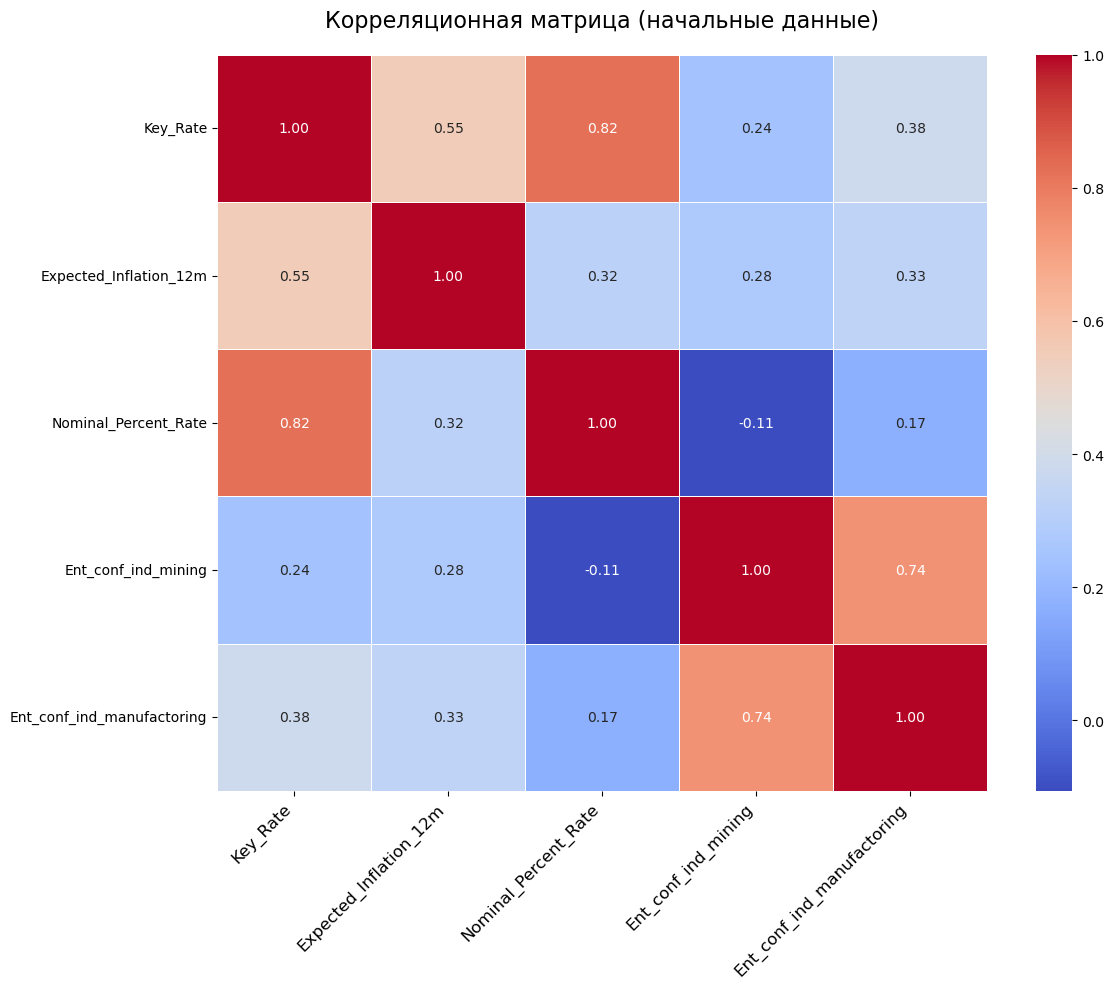

In [9]:
###############################
# КОРРЕЛЯЦИОННАЯ МАТРИЦА - ИСХОДНЫЕ ДАННЫЕ
###############################
dd = descriptive_df.corr()
plt.figure(figsize=(12, 10))
fig = sns.heatmap(dd, annot=True,
                  fmt=".2f",
                  linewidth=0.5,
                  linecolor='white',
                  annot_kws={"size": 10},
                  cmap='coolwarm')

fig.set_title("Корреляционная матрица (начальные данные)",
             fontsize=16, pad=20)

fig.set_xticklabels(fig.get_xticklabels(),
                   rotation=45,
                   ha='right',
                   fontsize=12)

plt.tight_layout()

In [10]:
###############################
    #VIF-анализ - начальные данные
###############################

vif_variables = [
    'Key_Rate',
    'Expected_Inflation_12m',
    'Nominal_Percent_Rate',
    'Ent_conf_ind_mining',
    'Ent_conf_ind_manufactoring'
]
df_vif = df_RF[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ДАННЫЕ")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ДАННЫЕ
                  Variable      VIF
                  Key_Rate 5.958574
      Nominal_Percent_Rate 4.998920
       Ent_conf_ind_mining 3.115443
Ent_conf_ind_manufactoring 2.605391
    Expected_Inflation_12m 1.584843


In [11]:
##############################
# Тест Фридмана на сезонность
##############################

variables_for_analysis = [
    ('Key_Rate', 'Ключевая ставка (Key_Rate)'),
    ('Expected_Inflation_12m', 'Ожидаемая инфляция на 12м'),
    ('Nominal_Percent_Rate', 'Номинальная ставка'),
    ('Ent_conf_ind_mining', 'Индекс уверенности (добыча)'),
    ('Ent_conf_ind_manufactoring', 'Индекс уверенности (обработка)')
]




In [12]:
# Применяем тест

friedman_results = []

for var_col, var_name in variables_for_analysis:
    if var_col in df_RF.columns:
        result = friedman_seasonality_test(df_RF, date_col='Date', 
                                          value_col=var_col, 
                                          test_name=var_name)
        if result:
            friedman_results.append(result)

# Сохраняем результаты Фридмана
friedman_summary = pd.DataFrame([
    {
        'Variable': r['variable'],
        'Chi_Squared': r['chi_squared'],
        'P_Value': r['p_value'],
        'Has_Seasonality': r['has_seasonality'],
        'N_Years': r['n_years'],
        'N_Months': r['n_months']
    } 
    for r in friedman_results
])

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ТЕСТОВ ФРИДМАНА")
print("="*80)
print(friedman_summary.to_string(index=False))

    



РЕЗУЛЬТАТЫ ТЕСТОВ ФРИДМАНА
                      Variable  Chi_Squared  P_Value  Has_Seasonality  N_Years  N_Months
    Ключевая ставка (Key_Rate)     0.741978 0.999989            False        6        12
     Ожидаемая инфляция на 12м    20.051282 0.044642             True        6        12
            Номинальная ставка    11.566303 0.397109            False        6        12
   Индекс уверенности (добыча)     8.051613 0.708673            False        6        12
Индекс уверенности (обработка)     3.872876 0.973489            False        6        12


[Ent_conf_ind_mining] Период: 2019-02, наблюдений: 84
[Ent_conf_ind_mining] Сезонная корректировка выполнена
[Ent_conf_ind_mining] Снижение волатильности: 0.1%
[Ent_conf_ind_manufactoring] Период: 2019-02, наблюдений: 84
[Ent_conf_ind_manufactoring] Сезонная корректировка выполнена
[Ent_conf_ind_manufactoring] Снижение волатильности: 0.4%
[Expected_Inflation_12m] Период: 2019-02, наблюдений: 84
[Expected_Inflation_12m] Сезонная корректировка выполнена
[Expected_Inflation_12m] Снижение волатильности: 7.0%

ПРОВЕРКА ДОБАВЛЕННЫХ СТОЛБЦОВ В DF_RF
Ent_conf_ind_mining_adj: 84 не-NaN значений
Ent_conf_ind_mining_trend: 84 не-NaN значений
Ent_conf_ind_mining_seasonal: 84 не-NaN значений
Ent_conf_ind_manufactoring_adj: 84 не-NaN значений
Ent_conf_ind_manufactoring_trend: 84 не-NaN значений
Ent_conf_ind_manufactoring_seasonal: 84 не-NaN значений
Expected_Inflation_12m_adj: 84 не-NaN значений
Expected_Inflation_12m_trend: 84 не-NaN значений
Expected_Inflation_12m_seasonal: 84 не-NaN значений

Все

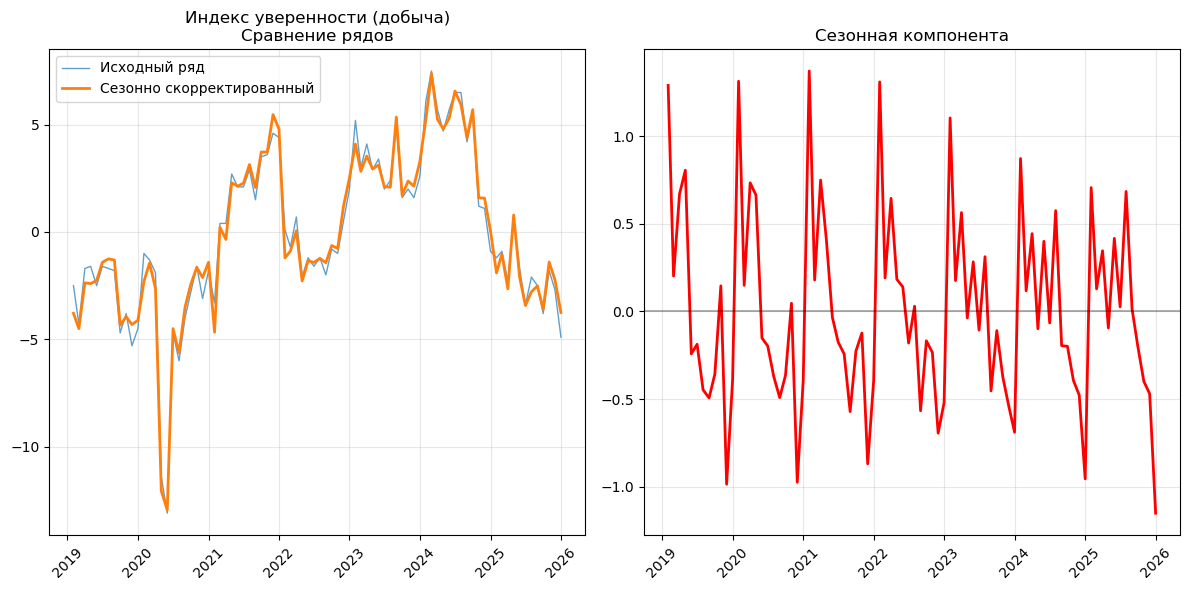

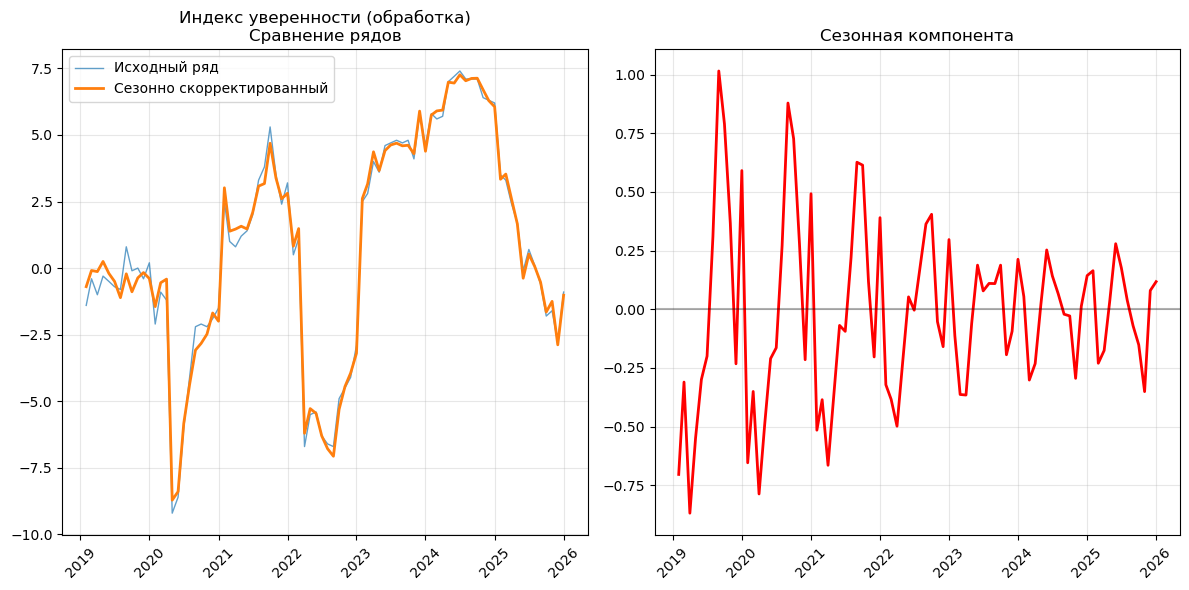

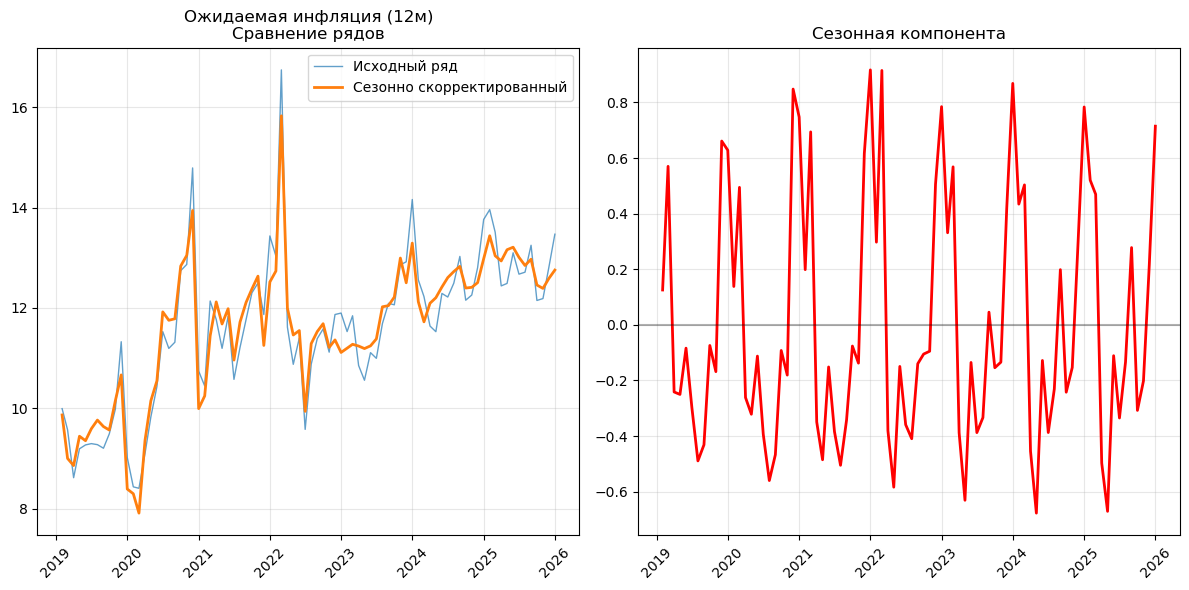

Все скорректированные ряды добавлены в df_RF
Столбцы с суффиксами: _adj, _trend, _seasonal


In [15]:
import json
from pathlib import Path

# Point to your settings file
json_path = Path("x13.json")  
# Load settings
with json_path.open(encoding="utf-8") as f:
    x13_settings = json.load(f)


# Путь к бинарнику X-13
X13_PATH = x13_settings['x13_path']   # либо каталог с бинарником, либо сам бинарник [web:2][web:8]

# Проверка, что бинарник доступен
if not os.path.exists(X13_PATH):
    raise FileNotFoundError(f"X-13 binary not found at {X13_PATH}")

# Если X13_PATH — полный путь к бинарнику, берем его директорию для x12path
x13_dir = X13_PATH if os.path.isdir(X13_PATH) else os.path.dirname(X13_PATH)

# Переменные для сезонной корректировки
x13_variables = {
    'Ent_conf_ind_mining': 'Индекс уверенности (добыча)',
    'Ent_conf_ind_manufactoring': 'Индекс уверенности (обработка)',
    'Expected_Inflation_12m': 'Ожидаемая инфляция (12м)',
}

os.makedirs("x13_logs", exist_ok=True)

for col, name in x13_variables.items():
    try:
        # Подготовка данных
        series_data = df_RF[['Date', col]].copy().dropna()

        if len(series_data) < 24:
            print(f"[{col}] Недостаточно данных ({len(series_data)} наблюдений). Пропуск.")
            continue

        # Устанавливаем Date как индекс и приводим к месячной частоте (start of month)
        temp_df = series_data.set_index('Date').asfreq('MS').dropna()

        if len(temp_df) < 24:
            print(f"[{col}] Менее 24 наблюдений после asfreq/NA. Пропуск.")
            continue

        print(f"[{col}] Период: {temp_df.index[0].year}-{temp_df.index[0].month:02d}, "
              f"наблюдений: {len(temp_df)}")

        # Вектор значений как pandas.Series с DatetimeIndex
        ts = temp_df[col]

        # Запуск X-13 (аналог seasonal::seas с SEATS)
        # По умолчанию statsmodels использует X-11; для полной эквивалентности
        # с SEATS могут потребоваться кастомные спецификации, но базовая декомпозиция
        # (seasadj, trend, irregular) доступна сразу. [web:2][web:8]
        res = x13_arima_analysis(
            endog=ts,
            x12path=x13_dir,
            prefer_x13=True,
            outlier=True,
            trading=False,
            print_stdout=False
        )

        # Компоненты (названия полей см. в документации statsmodels.X13ArimaAnalysisResult) [web:2][web:8]
        # seasadj: seasonally adjusted
        # trend: trend-cycle
        # irregular: остаток; сезонная компонента = исходный ряд - seasadj
        adj = res.seasadj
        trend = res.trend
        seas = ts - adj

        # Приведение к общему датафрейму
        df_RF.set_index('Date', inplace=True)

        # Создаем столбцы и заполняем только на пересечении индексов
        common_index = df_RF.index.intersection(ts.index)

        df_RF.loc[common_index, f'{col}_adj'] = adj.reindex(common_index)
        df_RF.loc[common_index, f'{col}_trend'] = trend.reindex(common_index)
        df_RF.loc[common_index, f'{col}_seasonal'] = seas.reindex(common_index)

        # Возвращаем индекс Date в столбец (если нужно)
        df_RF.reset_index(inplace=True)

        # Расчет эффективности (снижение волатильности)
        mask = ~df_RF[f'{col}_adj'].isna()
        if mask.any():
            original_std = df_RF.loc[mask, col].std()
            adj_std = df_RF.loc[mask, f'{col}_adj'].std()
            reduction = 100 * (1 - adj_std / original_std) if original_std > 0 else 0

            print(f"[{col}] Сезонная корректировка выполнена")
            print(f"[{col}] Снижение волатильности: {reduction:.1f}%")

    except Exception as e:
        print(f"[{col}] Ошибка: {e}")


# === ПРОВЕРКА ДОБАВЛЕННЫХ СТОЛБЦОВ ===
print("\n" + "="*60)
print("ПРОВЕРКА ДОБАВЛЕННЫХ СТОЛБЦОВ В DF_RF")
print("="*60)

added_columns = []
for col in x13_variables.keys():
    for suffix in ['_adj', '_trend', '_seasonal']:
        new_col = f'{col}{suffix}'
        if new_col in df_RF.columns:
            added_columns.append(new_col)
            non_na_count = df_RF[new_col].notna().sum()
            print(f"{new_col}: {non_na_count} не-NaN значений")

print(f"\nВсего добавлено столбцов: {len(added_columns)}")

# === СВОДКА РЕЗУЛЬТАТОВ ===
print("\n" + "="*60)
print("СВОДКА РЕЗУЛЬТАТОВ СЕЗОННОЙ КОРРЕКЦИИ")
print("="*60)

results_summary = []
for col, name in x13_variables.items():
    adj_col = f'{col}_adj'
    if adj_col in df_RF.columns:
        mask = ~df_RF[adj_col].isna()
        if mask.any():
            original_data = df_RF.loc[mask, col]
            adj_data = df_RF.loc[mask, adj_col]

            original_std = original_data.std()
            adj_std = adj_data.std()
            reduction = 100 * (1 - adj_std / original_std) if original_std > 0 else 0

            results_summary.append({
                'Переменная': name,
                'Снижение волатильности': f"{reduction:.1f}%",
                'До корректировки': f"{original_std:.4f}",
                'После корректировки': f"{adj_std:.4f}"
            })

if results_summary:
    summary_df = pd.DataFrame(results_summary)
    print(summary_df.to_string(index=False))

# === ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ===
print("\n" + "="*60)
print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("="*60)

for col, name in x13_variables.items():
    adj_col = f'{col}_adj'
    if adj_col in df_RF.columns:
        plot_data = df_RF[['Date', col, adj_col]].dropna(subset=[adj_col])

        if len(plot_data) > 0:
            plt.figure(figsize=(12, 6))

            plt.subplot(1, 2, 1)
            plt.plot(plot_data['Date'], plot_data[col],
                     label='Исходный ряд', alpha=0.7, linewidth=1)
            plt.plot(plot_data['Date'], plot_data[adj_col],
                     label='Сезонно скорректированный', linewidth=2)
            plt.title(f'{name}\nСравнение рядов')
            plt.legend()
            plt.grid(alpha=0.3)
            plt.xticks(rotation=45)

            plt.subplot(1, 2, 2)
            seasonal_col = f'{col}_seasonal'
            if seasonal_col in df_RF.columns:
                seasonal_data = df_RF[['Date', seasonal_col]].dropna(subset=[seasonal_col])
                plt.plot(seasonal_data['Date'], seasonal_data[seasonal_col],
                         color='red', linewidth=2)
                plt.title('Сезонная компонента')
                plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
                plt.grid(alpha=0.3)
                plt.xticks(rotation=45)

            plt.tight_layout()
            plt.show()

print("Все скорректированные ряды добавлены в df_RF")
print("Столбцы с суффиксами: _adj, _trend, _seasonal")

In [16]:
df_RF.columns

Index(['Date', 'Region', 'ROISFIX', 'Inflation_Expectations',
       'Nominal_Percent_Rate', 'MIACR', 'Oil_p', 'CPI', 'REER', 'Key_Rate',
       'Ent_conf_ind_mining', 'Ent_conf_ind_manufactoring', 'Covid_dum',
       'Sank_dum', 'MaP_Fact', 'MaP_Announcement', 'Mortgage_MaP_Fact',
       'Mortgage_MaP_Announcement', 'Conscred_MaP_Fact',
       'Conscred_MaP_Announcement', 'MaP_Tight_Fact', 'MaP_Ease_Fact',
       'MaP_Tight_Announcement', 'MaP_Ease_Announcement',
       'Mortgage_MaP_Tight_Fact', 'Mortgage_MaP_Ease_Fact',
       'Mortgage_MaP_Tight_Announcement', 'Mortgage_MaP_Ease_Announcement',
       'Conscred_MaP_Tight_Fact', 'Conscred_MaP_Ease_Fact',
       'Conscred_MaP_Tight_Announcement', 'Conscred_MaP_Ease_Announcement',
       'Month', 'Year', 'pi_current_year', 'pi_next_year',
       'Expected_Inflation_12m', 'Ent_conf_ind_mining_adj',
       'Ent_conf_ind_mining_trend', 'Ent_conf_ind_mining_seasonal',
       'Ent_conf_ind_manufactoring_adj', 'Ent_conf_ind_manufactoring_tre

In [17]:
##############################
# Тест Фридмана для рядов, скорректированных на сезонность
##############################

variables_for_analysis = [
    ('Expected_Inflation_12m_adj', 'Ожидаемая инфляция (12м)'),
    ('Ent_conf_ind_mining_adj', 'Индекс уверенности (добыча)'),
    ('Ent_conf_ind_manufactoring_adj', 'Индекс уверенности (обработка)')
]




In [18]:
# Применяем тест

friedman_results = []

for var_col, var_name in variables_for_analysis:
    if var_col in df_RF.columns:
        result = friedman_seasonality_test(df_RF, date_col='Date', 
                                          value_col=var_col, 
                                          test_name=var_name)
        if result:
            friedman_results.append(result)

# Сохраняем результаты Фридмана
friedman_summary = pd.DataFrame([
    {
        'Variable': r['variable'],
        'Chi_Squared': r['chi_squared'],
        'P_Value': r['p_value'],
        'Has_Seasonality': r['has_seasonality'],
        'N_Years': r['n_years'],
        'N_Months': r['n_months']
    } 
    for r in friedman_results
])

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ТЕСТОВ ФРИДМАНА")
print("="*60)
print(friedman_summary.to_string(index=False))

    



РЕЗУЛЬТАТЫ ТЕСТОВ ФРИДМАНА
                      Variable  Chi_Squared  P_Value  Has_Seasonality  N_Years  N_Months
      Ожидаемая инфляция (12м)     4.769231 0.941825            False        6        12
   Индекс уверенности (добыча)     5.358974 0.912544            False        6        12
Индекс уверенности (обработка)     2.487179 0.995919            False        6        12



РАСЧЕТ ИНДЕКСА ПРЕДПРИНИМАТЕЛЬСКОЙ УВЕРЕННОСТИ

Корреляция итогового индекса с компонентами:
  Итоговый - Добыча: 0.9165
  Итоговый - Обработка: 0.9448


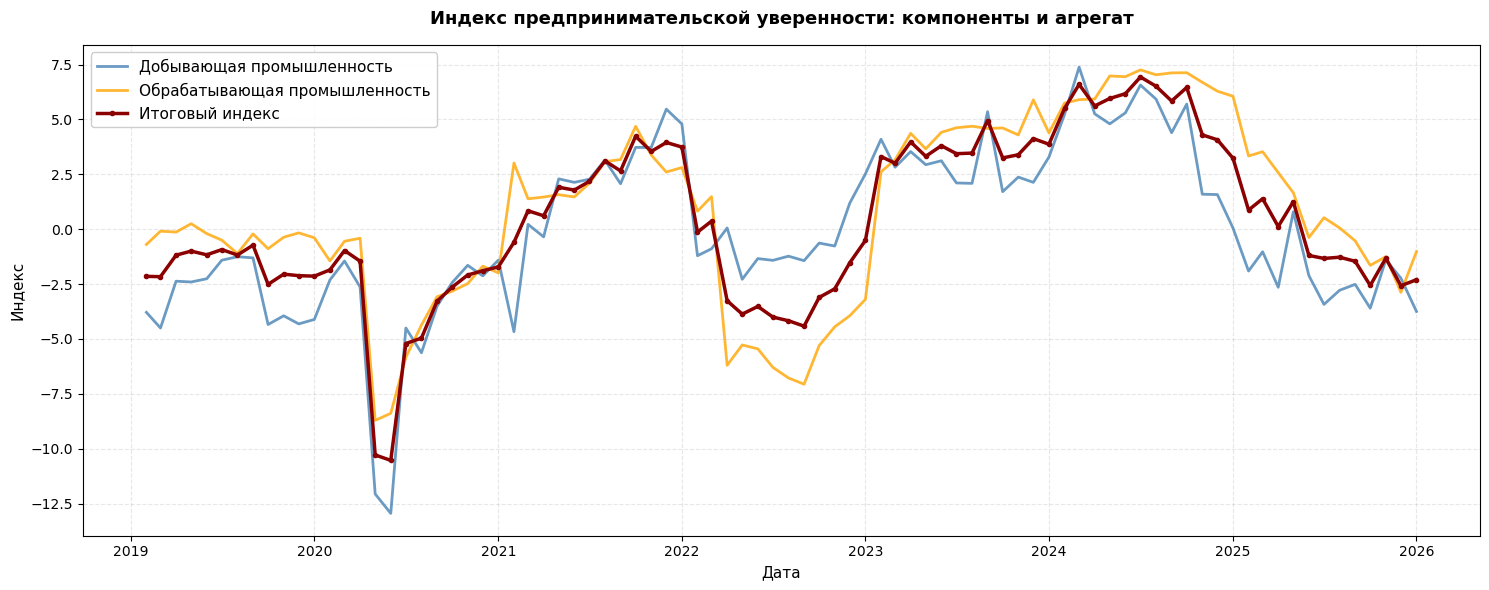

In [20]:
print("\n" + "="*60)
print("РАСЧЕТ ИНДЕКСА ПРЕДПРИНИМАТЕЛЬСКОЙ УВЕРЕННОСТИ")
print("="*60)

# Веса по доле в структуре промышленности РФ (2023 г.)
weights = {
    'mining': 0.47,              # Добывающая промышленность: 47%
    'manufacturing': 0.53        # Обрабатывающая промышленность: 53%
}

mining_col = 'Ent_conf_ind_mining_adj'
manuf_col = 'Ent_conf_ind_manufactoring_adj'     

# Проверяем доступность
mining_available = mining_col in df_RF.columns
manuf_available = manuf_col in df_RF.columns


if mining_available and manuf_available:
    # Берем скорректированные данные
    mining_series = df_RF[mining_col].copy()
    manuf_series = df_RF[manuf_col].copy()
    
    # Расчет взвешенного среднего
    df_RF['Ent_conf_ind_total'] = (
        weights['mining'] * mining_series + 
        weights['manufacturing'] * manuf_series
    )    

# Корреляция итогового индекса с компонентами
corr_total_mining = df_RF['Ent_conf_ind_total'].corr(mining_series)
corr_total_manuf = df_RF['Ent_conf_ind_total'].corr(manuf_series)

print(f"\nКорреляция итогового индекса с компонентами:")
print(f"  Итоговый - Добыча: {corr_total_mining:.4f}")
print(f"  Итоговый - Обработка: {corr_total_manuf:.4f}")


fig, ax1 = plt.subplots(figsize=(15, 6))

# График: Компоненты и итоговый индекс
ax1.plot(df_RF['Date'], mining_series, 
         label='Добывающая промышленность', linewidth=2, alpha=0.8, color='steelblue')
ax1.plot(df_RF['Date'], manuf_series, 
         label='Обрабатывающая промышленность', linewidth=2, alpha=0.8, color='orange')
ax1.plot(df_RF['Date'], df_RF['Ent_conf_ind_total'], 
         label='Итоговый индекс', 
         linewidth=2.5, color='darkred', linestyle='-', marker='o', markersize=3)

ax1.set_title('Индекс предпринимательской уверенности: компоненты и агрегат', 
              fontsize=13, fontweight='bold', pad=15)
ax1.legend(loc='best', fontsize=11, framealpha=0.95)
ax1.grid(alpha=0.3, linestyle='--')
ax1.set_ylabel('Индекс', fontsize=11)
ax1.set_xlabel('Дата', fontsize=11)
ax1.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()

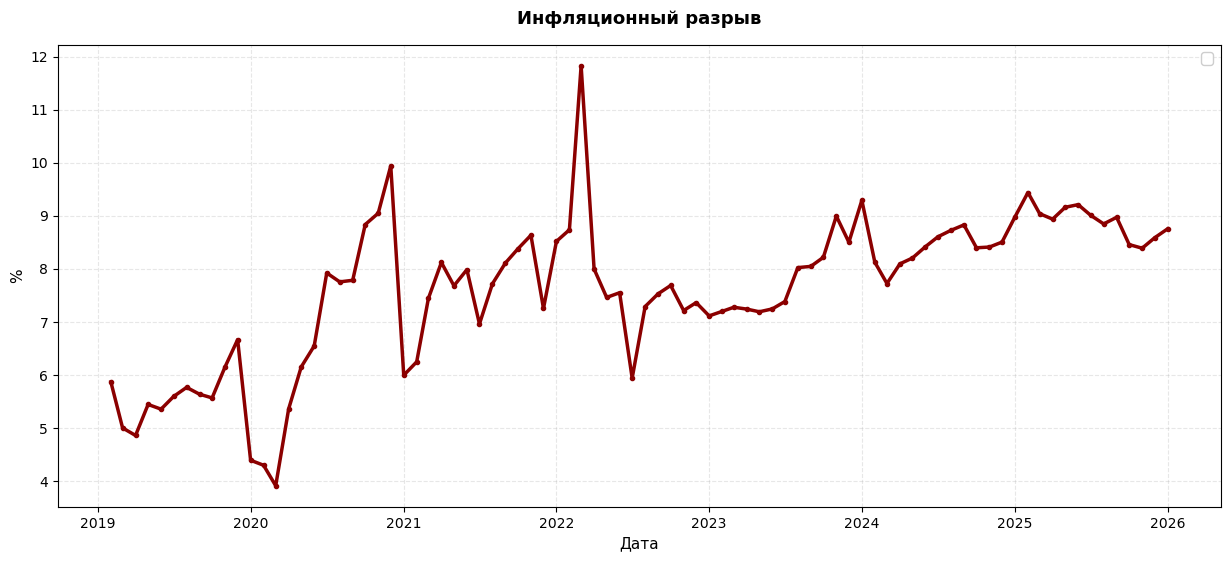

In [21]:
target_inflation = 4.0
df_RF['Inflation_gap'] =  df_RF['Expected_Inflation_12m_adj'] - target_inflation

fig, ax1 = plt.subplots(figsize=(15, 6))
ax1.plot(df_RF['Date'], df_RF['Inflation_gap'], 
         linewidth=2.5, color='darkred', linestyle='-', marker='o', markersize=3)
ax1.set_title('Инфляционный разрыв', 
              fontsize=13, fontweight='bold', pad=15)
ax1.legend(loc='best', fontsize=11, framealpha=0.95)
ax1.grid(alpha=0.3, linestyle='--')
ax1.set_ylabel('%', fontsize=11)
ax1.set_xlabel('Дата', fontsize=11)
ax1.tick_params(axis='both', labelsize=10)

In [22]:
df_taylor = df_RF[['Date','Key_Rate', 'Inflation_gap', 'Nominal_Percent_Rate', 'Ent_conf_ind_total', 'Expected_Inflation_12m_adj']]
df_taylor.head()

,Date,Key_Rate,Inflation_gap,Nominal_Percent_Rate,Ent_conf_ind_total,Expected_Inflation_12m_adj
0,2019-02-01,7.75,5.868338,6.5,-2.149525,9.868338
1,2019-03-01,7.75,5.001894,6.5,-2.163221,9.001894
2,2019-04-01,7.75,4.859625,6.5,-1.183216,8.859625
3,2019-05-01,7.75,5.444210,6.5,-0.997827,9.444210
4,2019-06-01,7.75,5.355325,6.5,-1.167549,9.355325



РЕЗУЛЬТАТЫ ТЕСТА ЛЬЮИНГА-БОКСА

1. Ставка Key_Rate
   Тип данных: Исходный
   Наблюдения: 84
   Тестовые лаги: 19
   Ljung-Box статистика: 558.607
   P-значение: 0.000000
   ✗ ОБНАРУЖЕНА АВТОКОРРЕЛЯЦИЯ (p < 0.05)
   Ключевые лаги:
     Лаг  1: p=0.000000 ✗
     Лаг  3: p=0.000000 ✗
     Лаг  6: p=0.000000 ✗
     Лаг 12: p=0.000000 ✗

2. Инфляционный разрыв
   Тип данных: Исходный
   Наблюдения: 84
   Тестовые лаги: 19
   Ljung-Box статистика: 219.277
   P-значение: 0.000000
   ✗ ОБНАРУЖЕНА АВТОКОРРЕЛЯЦИЯ (p < 0.05)
   Ключевые лаги:
     Лаг  1: p=0.000000 ✗
     Лаг  3: p=0.000000 ✗
     Лаг  6: p=0.000000 ✗
     Лаг 12: p=0.000000 ✗

3. Нейтральная ставка
   Тип данных: Исходный
   Наблюдения: 84
   Тестовые лаги: 19
   Ljung-Box статистика: 484.026
   P-значение: 0.000000
   ✗ ОБНАРУЖЕНА АВТОКОРРЕЛЯЦИЯ (p < 0.05)
   Ключевые лаги:
     Лаг  1: p=0.000000 ✗
     Лаг  3: p=0.000000 ✗
     Лаг  6: p=0.000000 ✗
     Лаг 12: p=0.000000 ✗

4. Индекс уверенности
   Тип данных: Исходный
  

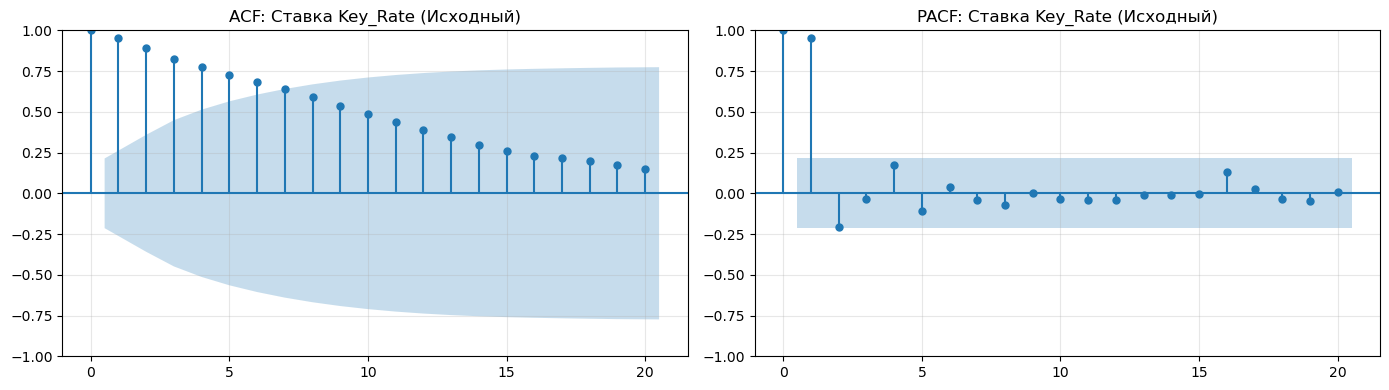

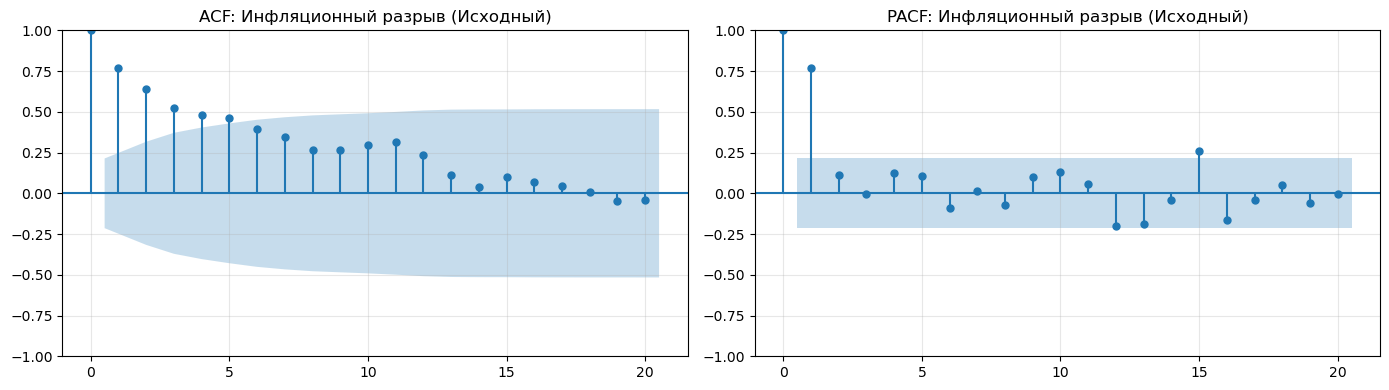

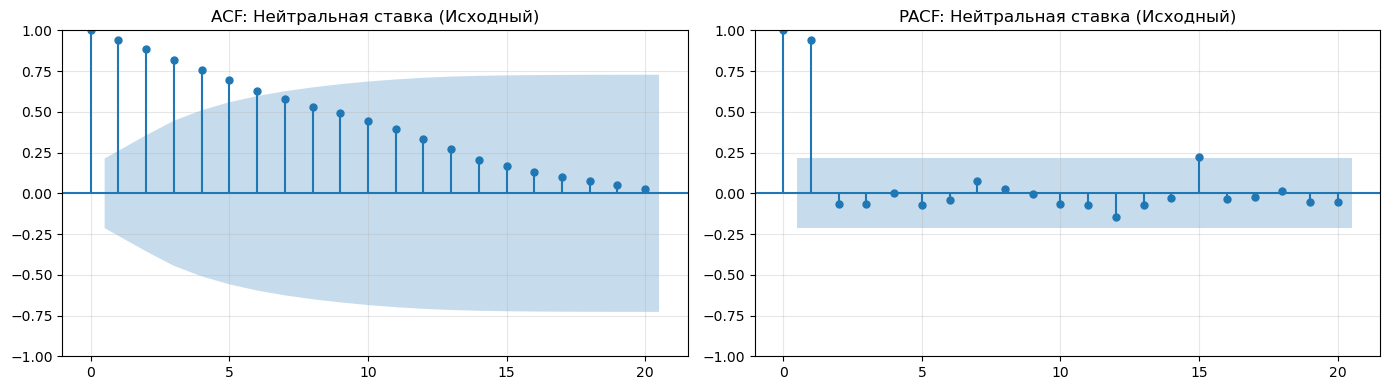

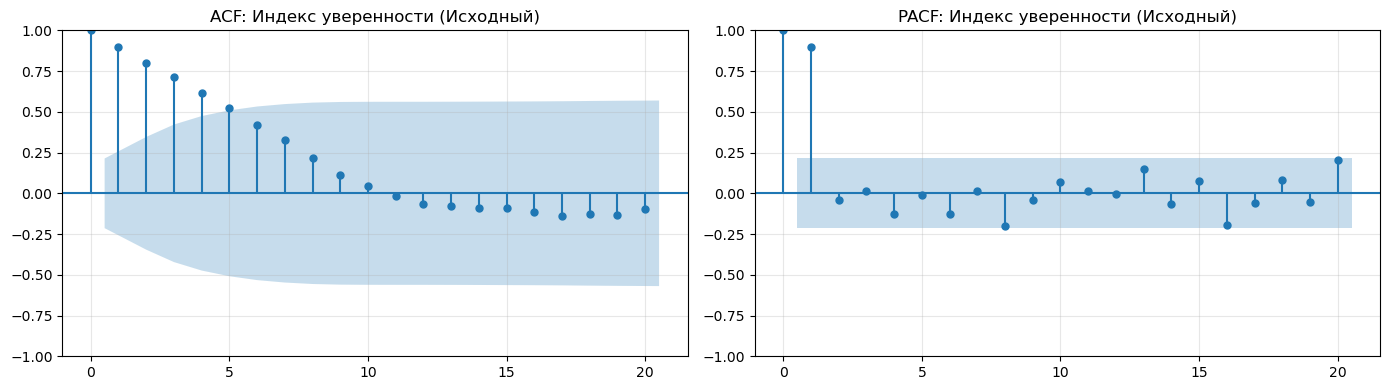

In [23]:
###############################
# Тест Льюинга-Бокса до перехода к разностям
###############################

# === ПЕРЕМЕННЫЕ ДЛЯ ТЕСТА ===
test_variables = {
    'Key_Rate': 'Ставка Key_Rate',
    'Inflation_gap': 'Инфляционный разрыв',
    'Nominal_Percent_Rate': 'Нейтральная ставка',
    'Ent_conf_ind_total': 'Индекс уверенности'
}

# === ФУНКЦИЯ 1: Определяет какой ряд использовать (adj или исходный) ===

# === ФУНКЦИЯ 2: Тест Льюинга-Бокса ===

# === ОСНОВНОЙ АНАЛИЗ ===


ljungbox_results = []
problematic_series = []

for col, name in test_variables.items():
    if col not in df_taylor.columns:
        print(f"✗ {name}: столбец '{col}' не найден в df_taylor")
        continue
    
    # Определяем какой ряд использовать
    series, source_type = get_series_for_test(df_taylor, col)
    
    if len(series) < 10:
        print(f"✗ {name}: недостаточно данных (n={len(series)})")
        continue
    
    # Выполняем тест
    result = optimized_ljung_box_test(series, name, source_type)
    
    if result:
        ljungbox_results.append(result)

# === ВЫВОД РЕЗУЛЬТАТОВ ===

print("\n" + "="*70)
print("РЕЗУЛЬТАТЫ ТЕСТА ЛЬЮИНГА-БОКСА")
print("="*70)

if ljungbox_results:
    for i, result in enumerate(ljungbox_results, 1):
        print(f"\n{i}. {result['name']}")
        print(f"   Тип данных: {result['source_type']}")
        print(f"   Наблюдения: {result['n_obs']}")
        print(f"   Тестовые лаги: {result['test_lags']}")
        print(f"   Ljung-Box статистика: {result['lb_statistic']:.3f}")
        print(f"   P-значение: {result['p_value']:.6f}")
        
        if result['is_white_noise']:
            print(f"   ✓ ОСТАТКИ БЕЗ АВТОКОРРЕЛЯЦИИ (p > 0.05)")
        else:
            print(f"   ✗ ОБНАРУЖЕНА АВТОКОРРЕЛЯЦИЯ (p < 0.05)")
            problematic_series.append(result)
        
        # Ключевые лаги
        print(f"   Ключевые лаги:")
        for key_res in result['key_lags_results']:
            sig_mark = "✓" if key_res['pvalue'] > 0.05 else "✗"
            print(f"     Лаг {key_res['lag']:2d}: p={key_res['pvalue']:.6f} {sig_mark}")

# === СВОДНАЯ ТАБЛИЦА ===

if ljungbox_results:
    print("\n" + "="*70)
    print("СВОДНАЯ ТАБЛИЦА")
    print("="*70)
    
    summary_data = []
    for result in ljungbox_results:
        # Подсчитываем количество значимых лагов из ключевых
        sig_lags = sum(1 for res in result['key_lags_results'] if res['pvalue'] < 0.05)
        total_lags = len(result['key_lags_results'])
        
        # Определяем статус
        if result['is_white_noise']:
            status = "✓ OK"
        elif sig_lags <= 2:
            status = "⚠ Приемлемо"
        else:
            status = "✗ Проблема"
        
        summary_data.append({
            'Переменная': result['name'],
            'Тип данных': result['source_type'],
            'N': result['n_obs'],
            'P-значение': f"{result['p_value']:.6f}",
            'Значимые лаги': f"{sig_lags}/{total_lags}",
            'Статус': status
        })
    
    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))

# === ВИЗУАЛИЗАЦИЯ ACF/PACF ДЛЯ ПРОБЛЕМНЫХ РЯДОВ ===

print("\n" + "="*70)
print("ВИЗУАЛИЗАЦИЯ ACF/PACF")
print("="*70)

# Визуализируем только для проблемных рядов
if problematic_series:
    for result in problematic_series:
        col_name = None
        for col, name in test_variables.items():
            if name == result['name']:
                col_name = col
                break
        
        if col_name:
            series = result['series']
            
            fig, axes = plt.subplots(1, 2, figsize=(14, 4))
            
            # ACF
            plot_acf(series, lags=min(20, len(series)-1), ax=axes[0], alpha=0.05)
            axes[0].set_title(f'ACF: {result["name"]} ({result["source_type"]})')
            axes[0].grid(alpha=0.3)
            
            # PACF
            plot_pacf(series, lags=min(20, len(series)-1), ax=axes[1], alpha=0.05)
            axes[1].set_title(f'PACF: {result["name"]} ({result["source_type"]})')
            axes[1].grid(alpha=0.3)
            
            plt.tight_layout()
            plt.show()
else:
    print("\n✓ Нет проблемных рядов - все переменные имеют приемлемый уровень автокорреляции!")

In [24]:
###############################
    #Тесты на стационарность до перехода к разностям
###############################
variables_to_test = [
    'Key_Rate',
    'Inflation_gap',
    'Nominal_Percent_Rate',
    'Ent_conf_ind_total',
    'Expected_Inflation_12m_adj'
]

df_test = df_taylor[variables_to_test]

stationarity_results = []
for var in df_test.columns:
    result = stationarity_tests(df_test[var], var)
    stationarity_results.append(result)

stationarity_df = pd.DataFrame(stationarity_results)
print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ТЕСТОВ НА СТАЦИОНАРНОСТЬ ДЛЯ НАЧАЛЬНЫХ ДАННЫХ")
print("="*60)
print(stationarity_df.to_string())


РЕЗУЛЬТАТЫ ТЕСТОВ НА СТАЦИОНАРНОСТЬ ДЛЯ НАЧАЛЬНЫХ ДАННЫХ
                     Variable  ADF_Statistic  ADF_p_value  ADF_Critical_1%  ADF_Critical_5%  ADF_Critical_10%  ADF_Stationary  KPSS_Statistic  KPSS_p_value  KPSS_Critical_1%  KPSS_Critical_5%  KPSS_Critical_10%  KPSS_Stationary  DF_GLS_Statistic  DF_GLS_p_value  DF_GLS_Critical_1%  DF_GLS_Critical_5%  DF_GLS_Critical_10%  DF_GLS_Stationary
0                    Key_Rate      -1.192667     0.676742        -3.511712        -2.897048         -2.585713           False        1.105499      0.010000             0.739             0.463              0.347            False         -1.013306        0.287554           -2.792085           -2.171517            -1.860401              False
1               Inflation_gap      -3.222283     0.018731        -3.511712        -2.897048         -2.585713            True        0.951659      0.010000             0.739             0.463              0.347            False         -2.430461        0.015

In [25]:
###############################
    #Подготовка финального датасета (добавляем дамми, лаги и прозведения)
###############################

df_taylor['Covid_dum'] = df_RF['Covid_dum']
df_taylor['Sank_dum'] = df_RF['Sank_dum']
df_taylor['L1_Inflation_gap'] = df_taylor['Inflation_gap'].shift(1)
df_taylor['L1_Ent_conf_ind_total'] = df_taylor['Ent_conf_ind_total'].shift(1)
df_taylor['L1_Nominal_Percent_Rate'] = df_taylor['Nominal_Percent_Rate'].shift(1)  
df_taylor['L1_Key_Rate'] = df_taylor['Key_Rate'].shift(1)

df_taylor = df_taylor.dropna()
df_taylor.head()

,Date,Key_Rate,Inflation_gap,Nominal_Percent_Rate,Ent_conf_ind_total,Expected_Inflation_12m_adj,Covid_dum,Sank_dum,L1_Inflation_gap,L1_Ent_conf_ind_total,L1_Nominal_Percent_Rate,L1_Key_Rate
1,2019-03-01,7.75,5.001894,6.5,-2.163221,9.001894,0,0,5.868338,-2.149525,6.5,7.75
2,2019-04-01,7.75,4.859625,6.5,-1.183216,8.859625,0,0,5.001894,-2.163221,6.5,7.75
3,2019-05-01,7.75,5.444210,6.5,-0.997827,9.444210,0,0,4.859625,-1.183216,6.5,7.75
4,2019-06-01,7.75,5.355325,6.5,-1.167549,9.355325,0,0,5.444210,-0.997827,6.5,7.75
5,2019-07-01,7.50,5.594339,6.5,-0.929078,9.594339,0,0,5.355325,-1.167549,6.5,7.75


In [26]:
###############################
# Тест White и Breusch-Pagan на гетероскедастичность
###############################
print("\n" + "="*60)
print("ТЕСТЫ НА ГЕТЕРОСКЕДАСТИЧНОСТЬ: WHITE И BREUSCH-PAGAN")
print("="*60)

# Подготавливаем данные для регрессии
X = sm.add_constant(df_taylor[['Inflation_gap', 'Nominal_Percent_Rate', 'Ent_conf_ind_total']])
y = df_taylor['Key_Rate']

# Строим базовую модель OLS
model_ols = sm.OLS(y, X).fit()

# Получаем остатки
residuals = model_ols.resid

print("\nРегрессионная модель:")
print(f"Зависимая переменная: Key_Rate")
print(f"Количество наблюдений: {len(y)}")
print(f"R-squared: {model_ols.rsquared:.4f}")

# === ТЕСТ BREUSCH-PAGAN ===
print("\n" + "-"*60)
print("ТЕСТ BREUSCH-PAGAN")
print("-"*60)
print("H0: Гомоскедастичность (константная дисперсия)")
print("H1: Гетероскедастичность (переменная дисперсия)\n")

bp_stat, bp_pvalue, bp_f_stat, bp_f_pvalue = het_breuschpagan(residuals, X)

print(f"LM-статистика Breusch-Pagan: {bp_stat:.4f}")
print(f"P-значение (LM): {bp_pvalue:.6f}")
print(f"F-статистика: {bp_f_stat:.4f}")
print(f"P-значение (F): {bp_f_pvalue:.6f}")

if bp_pvalue < 0.05:
    print("\n ОТКЛОНЯЕМ H0: ОБНАРУЖЕНА ГЕТЕРОСКЕДАСТИЧНОСТЬ (p < 0.05)")
else:
    print("\n ПРИНИМАЕМ H0: НЕТ ЗНАЧИМОЙ ГЕТЕРОСКЕДАСТИЧНОСТИ (p > 0.05)")

# === ТЕСТ WHITE ===
print("\n" + "-"*80)
print("ТЕСТ WHITE")
print("-"*80)
print("H0: Гомоскедастичность (константная дисперсия)")
print("H1: Гетероскедастичность (переменная дисперсия)\n")

white_stat, white_pvalue, white_df, white_fitted = het_white(residuals, X)

print(f"LM-статистика White: {white_stat:.4f}")
print(f"P-значение: {white_pvalue:.6f}")
print(f"Степени свободы: {white_df}")

if white_pvalue < 0.05:
    print("\n ОТКЛОНЯЕМ H0: ОБНАРУЖЕНА ГЕТЕРОСКЕДАСТИЧНОСТЬ (p < 0.05)")
else:
    print("\n ПРИНИМАЕМ H0: НЕТ ЗНАЧИМОЙ ГЕТЕРОСКЕДАСТИЧНОСТИ (p > 0.05)")

# === СВОДНАЯ ТАБЛИЦА ===
print("\n" + "="*60)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*60)

summary_heteroscedasticity = pd.DataFrame({
    'Тест': ['Breusch-Pagan (LM)', 'Breusch-Pagan (F)', 'White'],
    'Статистика': [f"{bp_stat:.4f}", f"{bp_f_stat:.4f}", f"{white_stat:.4f}"],
    'P-значение': [f"{bp_pvalue:.6f}", f"{bp_f_pvalue:.6f}", f"{white_pvalue:.6f}"],
    'Вывод': [
        ' Гетероскедастичность' if bp_pvalue < 0.05 else ' Гомоскедастичность',
        ' Гетероскедастичность' if bp_f_pvalue < 0.05 else ' Гомоскедастичность',
        ' Гетероскедастичность' if white_pvalue < 0.05 else ' Гомоскедастичность'
    ]
})

print(summary_heteroscedasticity.to_string(index=False))


ТЕСТЫ НА ГЕТЕРОСКЕДАСТИЧНОСТЬ: WHITE И BREUSCH-PAGAN

Регрессионная модель:
Зависимая переменная: Key_Rate
Количество наблюдений: 83
R-squared: 0.8163

------------------------------------------------------------
ТЕСТ BREUSCH-PAGAN
------------------------------------------------------------
H0: Гомоскедастичность (константная дисперсия)
H1: Гетероскедастичность (переменная дисперсия)

LM-статистика Breusch-Pagan: 18.4069
P-значение (LM): 0.000363
F-статистика: 7.5041
P-значение (F): 0.000176

 ОТКЛОНЯЕМ H0: ОБНАРУЖЕНА ГЕТЕРОСКЕДАСТИЧНОСТЬ (p < 0.05)

--------------------------------------------------------------------------------
ТЕСТ WHITE
--------------------------------------------------------------------------------
H0: Гомоскедастичность (константная дисперсия)
H1: Гетероскедастичность (переменная дисперсия)

LM-статистика White: 42.5609
P-значение: 0.000003
Степени свободы: 8.536692932753363

 ОТКЛОНЯЕМ H0: ОБНАРУЖЕНА ГЕТЕРОСКЕДАСТИЧНОСТЬ (p < 0.05)

СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ

In [27]:
###############################
# МОДЕЛЬ 1: БАЗОВАЯ (без dummy)
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 1: БАЗОВАЯ ARDL (1, 0, 0, 0) БЕЗ DUMMY")
print("="*60)

formula1 = """Key_Rate ~ 
            L1_Key_Rate +
            Inflation_gap + 
            Nominal_Percent_Rate + 
            Ent_conf_ind_total
            """

model1 = ols(formula1, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model1.summary())
coeffs = extract_ardl_coefficients(model1, y_name='Key_Rate', print_results=True)


МОДЕЛЬ 1: БАЗОВАЯ ARDL (1, 0, 0, 0) БЕЗ DUMMY
                            OLS Regression Results                            
Dep. Variable:               Key_Rate   R-squared:                       0.948
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     641.8
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           8.04e-59
Time:                        17:39:53   Log-Likelihood:                -140.67
No. Observations:                  83   AIC:                             291.3
Df Residuals:                      78   BIC:                             303.4
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

In [28]:
###############################
# МОДЕЛЬ 2: с дамми для 2022 и для ковида
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 2: ARDL (1, 0, 0, 0) С DUMMY")
print("="*60)

formula2 = """Key_Rate ~ 
            L1_Key_Rate +
            Inflation_gap + 
            Nominal_Percent_Rate + 
            Ent_conf_ind_total +
            Sank_dum +
            Covid_dum
            """

model2 = ols(formula2, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model2.summary())
coeffs = extract_ardl_coefficients(model2, y_name='Key_Rate', print_results=True)


МОДЕЛЬ 2: ARDL (1, 0, 0, 0) С DUMMY
                            OLS Regression Results                            
Dep. Variable:               Key_Rate   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     454.1
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           2.21e-57
Time:                        17:39:57   Log-Likelihood:                -137.74
No. Observations:                  83   AIC:                             289.5
Df Residuals:                      76   BIC:                             306.4
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------

In [29]:
###############################
# МОДЕЛЬ 3: с лагаом inf_gap разрыва без дамми 
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 3: ARDL (1, 1, 0, 0) БЕЗ DUMMY ")
print("="*60)

formula3 = """Key_Rate ~ 
            L1_Key_Rate +
            Inflation_gap + 
            L1_Inflation_gap +
            Nominal_Percent_Rate +
            Ent_conf_ind_total
            """

model3 = ols(formula3, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model3.summary())
coeffs = extract_ardl_coefficients(model3, y_name='Key_Rate', print_results=True)


МОДЕЛЬ 3: ARDL (1, 1, 0, 0) БЕЗ DUMMY 
                            OLS Regression Results                            
Dep. Variable:               Key_Rate   R-squared:                       0.948
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     564.9
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           3.78e-59
Time:                        17:40:02   Log-Likelihood:                -140.48
No. Observations:                  83   AIC:                             293.0
Df Residuals:                      77   BIC:                             307.5
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------

In [30]:
###############################
# МОДЕЛЬ 4: с лагом inf_gap разрыва с дамми 
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 4: ARDL (1, 1, 0, 0) С DUMMY ")
print("="*60)



formula4 = """Key_Rate ~ 
            L1_Key_Rate +
            Inflation_gap + 
            L1_Inflation_gap +
            Nominal_Percent_Rate +
            Ent_conf_ind_total +
            Sank_dum +
            Covid_dum
            """

model4 = ols(formula4, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model4.summary())
coeffs = extract_ardl_coefficients(model4, y_name='Key_Rate', print_results=True)


МОДЕЛЬ 4: ARDL (1, 1, 0, 0) С DUMMY 
                            OLS Regression Results                            
Dep. Variable:               Key_Rate   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.947
Method:                 Least Squares   F-statistic:                     399.8
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           1.15e-56
Time:                        17:40:05   Log-Likelihood:                -137.72
No. Observations:                  83   AIC:                             291.4
Df Residuals:                      75   BIC:                             310.8
Df Model:                           7                                         
Covariance Type:                  HAC                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------

In [31]:
###############################
# МОДЕЛЬ 5: ARDL с лагом r* без дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 5: ARDL (1, 0, 1, 0) БЕЗ DUMMY")
print("="*60)

formula5 = """Key_Rate ~ 
            L1_Key_Rate +
            Inflation_gap + 
            Nominal_Percent_Rate +
            L1_Nominal_Percent_Rate +
            Ent_conf_ind_total 
            """

model5 = ols(formula5, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model5.summary())
coeffs = extract_ardl_coefficients(model5, y_name='Key_Rate', print_results=True)


МОДЕЛЬ 5: ARDL (1, 0, 1, 0) БЕЗ DUMMY
                            OLS Regression Results                            
Dep. Variable:               Key_Rate   R-squared:                       0.961
Model:                            OLS   Adj. R-squared:                  0.958
Method:                 Least Squares   F-statistic:                     601.3
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           3.64e-60
Time:                        17:40:09   Log-Likelihood:                -128.92
No. Observations:                  83   AIC:                             269.8
Df Residuals:                      77   BIC:                             284.4
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------

In [32]:
###############################
# МОДЕЛЬ 6: ARDL с лагом r* С дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 6: ARDL (1, 0, 1, 0) С DUMMY")
print("="*60)

formula6 = """Key_Rate ~ 
            L1_Key_Rate +
            Inflation_gap + 
            Nominal_Percent_Rate +
            L1_Nominal_Percent_Rate +
            Ent_conf_ind_total +
            Sank_dum +
            Covid_dum
            """

model6 = ols(formula6, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model6.summary())
coeffs = extract_ardl_coefficients(model6, y_name='Key_Rate', print_results=True)


МОДЕЛЬ 6: ARDL (1, 0, 1, 0) С DUMMY
                            OLS Regression Results                            
Dep. Variable:               Key_Rate   R-squared:                       0.962
Model:                            OLS   Adj. R-squared:                  0.958
Method:                 Least Squares   F-statistic:                     390.4
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           2.73e-56
Time:                        17:40:10   Log-Likelihood:                -127.76
No. Observations:                  83   AIC:                             271.5
Df Residuals:                      75   BIC:                             290.9
Df Model:                           7                                         
Covariance Type:                  HAC                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------

In [33]:
###############################
# МОДЕЛЬ 7: ARDL с лагом y_gap БЕЗ дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 7: ARDL (1, 0, 0, 1) БЕЗ DUMMY")
print("="*60)

formula7 = """Key_Rate ~ 
            L1_Key_Rate +
            Inflation_gap + 
            Nominal_Percent_Rate +
            Ent_conf_ind_total +
            L1_Ent_conf_ind_total
            """

model7 = ols(formula7, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model7.summary())
coeffs = extract_ardl_coefficients(model6, y_name='Key_Rate', print_results=True)


МОДЕЛЬ 7: ARDL (1, 0, 0, 1) БЕЗ DUMMY
                            OLS Regression Results                            
Dep. Variable:               Key_Rate   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                     534.1
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           3.07e-58
Time:                        17:40:18   Log-Likelihood:                -139.25
No. Observations:                  83   AIC:                             290.5
Df Residuals:                      77   BIC:                             305.0
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------

In [34]:
###############################
# МОДЕЛЬ 8: ARDL с лагом y_gap с дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 8: ARDL (1, 0, 0, 1) С DUMMY")
print("="*60)

formula8 = """Key_Rate ~ 
            L1_Key_Rate +
            Inflation_gap + 
            Nominal_Percent_Rate +
            Ent_conf_ind_total +
            L1_Ent_conf_ind_total +
            Covid_dum +
            Sank_dum
            """

model8 = ols(formula8, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model8.summary())
coeffs = extract_ardl_coefficients(model8, y_name='Key_Rate', print_results=True)


МОДЕЛЬ 8: ARDL (1, 0, 0, 1) С DUMMY
                            OLS Regression Results                            
Dep. Variable:               Key_Rate   R-squared:                       0.953
Model:                            OLS   Adj. R-squared:                  0.949
Method:                 Least Squares   F-statistic:                     425.4
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           1.19e-57
Time:                        17:40:20   Log-Likelihood:                -136.18
No. Observations:                  83   AIC:                             288.4
Df Residuals:                      75   BIC:                             307.7
Df Model:                           7                                         
Covariance Type:                  HAC                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------

In [35]:
###############################
# МОДЕЛЬ 9: ARDL с лагом inf_gap и r* без дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 9: ARDL (1, 1, 1, 0) БЕЗ DUMMY")
print("="*60)

formula9 = """Key_Rate ~ 
            L1_Key_Rate +
            Inflation_gap + 
            L1_Inflation_gap+
            Nominal_Percent_Rate +
            L1_Nominal_Percent_Rate+
            Ent_conf_ind_total
            """

model9 = ols(formula9, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model9.summary())
coeffs = extract_ardl_coefficients(model9, y_name='Key_Rate', print_results=True)


МОДЕЛЬ 9: ARDL (1, 1, 1, 0) БЕЗ DUMMY
                            OLS Regression Results                            
Dep. Variable:               Key_Rate   R-squared:                       0.961
Model:                            OLS   Adj. R-squared:                  0.958
Method:                 Least Squares   F-statistic:                     485.2
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           1.91e-58
Time:                        17:40:25   Log-Likelihood:                -128.67
No. Observations:                  83   AIC:                             271.3
Df Residuals:                      76   BIC:                             288.3
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------

In [36]:
###############################
# МОДЕЛЬ 10: ARDL с лагом inf_gap и r* с дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 10: ARDL (1, 1, 1, 0) С DUMMY")
print("="*60)

formula10 = """Key_Rate ~ 
            L1_Key_Rate +
            Inflation_gap + 
            L1_Inflation_gap+
            Nominal_Percent_Rate +
            L1_Nominal_Percent_Rate+
            Ent_conf_ind_total +
            Covid_dum +
            Sank_dum
            """

model10 = ols(formula10, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model10.summary())
coeffs = extract_ardl_coefficients(model10, y_name='Key_Rate', print_results=True)


МОДЕЛЬ 10: ARDL (1, 1, 1, 0) С DUMMY
                            OLS Regression Results                            
Dep. Variable:               Key_Rate   R-squared:                       0.962
Model:                            OLS   Adj. R-squared:                  0.958
Method:                 Least Squares   F-statistic:                     329.5
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           1.26e-54
Time:                        17:40:28   Log-Likelihood:                -127.34
No. Observations:                  83   AIC:                             272.7
Df Residuals:                      74   BIC:                             294.4
Df Model:                           8                                         
Covariance Type:                  HAC                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------

In [37]:
###############################
# МОДЕЛЬ 11: ARDL с лагом inf_gap и y_gap без дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 11: ARDL (1, 1, 0, 1) БЕЗ DUMMY")
print("="*60)

formula11 = """Key_Rate ~ 
            L1_Key_Rate +
            Inflation_gap + 
            L1_Inflation_gap +
            Nominal_Percent_Rate +
            Ent_conf_ind_total +
            L1_Ent_conf_ind_total
            """

model11 = ols(formula11, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model11.summary())
coeffs = extract_ardl_coefficients(model11, y_name='Key_Rate', print_results=True)


МОДЕЛЬ 11: ARDL (1, 1, 0, 1) БЕЗ DUMMY
                            OLS Regression Results                            
Dep. Variable:               Key_Rate   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                     538.5
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           4.01e-60
Time:                        17:40:33   Log-Likelihood:                -139.05
No. Observations:                  83   AIC:                             292.1
Df Residuals:                      76   BIC:                             309.0
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------

In [38]:
###############################
# МОДЕЛЬ 12: ARDL с лагом inf_gap и y_gap с дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 12: ARDL (1, 1, 0, 1) С DUMMY")
print("="*60)

formula12 = """Key_Rate ~ 
            L1_Key_Rate +
            Inflation_gap + 
            L1_Inflation_gap +
            Nominal_Percent_Rate +
            Ent_conf_ind_total +
            L1_Ent_conf_ind_total +
            Covid_dum +
            Sank_dum
            """

model12 = ols(formula12, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model12.summary())
coeffs = extract_ardl_coefficients(model12, y_name='Key_Rate', print_results=True)


МОДЕЛЬ 12: ARDL (1, 1, 0, 1) С DUMMY
                            OLS Regression Results                            
Dep. Variable:               Key_Rate   R-squared:                       0.953
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     380.2
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           7.34e-57
Time:                        17:40:36   Log-Likelihood:                -136.16
No. Observations:                  83   AIC:                             290.3
Df Residuals:                      74   BIC:                             312.1
Df Model:                           8                                         
Covariance Type:                  HAC                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------

In [39]:
###############################
# МОДЕЛЬ 13: ARDL с лагом r* и y_gap без дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 13: ARDL (1, 0, 1, 1) БЕЗ DUMMY")
print("="*60)

formula13 = """Key_Rate ~ 
            L1_Key_Rate +
            Inflation_gap + 
            Nominal_Percent_Rate +
            L1_Nominal_Percent_Rate +
            Ent_conf_ind_total +
            L1_Ent_conf_ind_total
            """

model13 = ols(formula13, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model13.summary())
coeffs = extract_ardl_coefficients(model11, y_name='Key_Rate', print_results=True)


МОДЕЛЬ 13: ARDL (1, 0, 1, 1) БЕЗ DUMMY
                            OLS Regression Results                            
Dep. Variable:               Key_Rate   R-squared:                       0.962
Model:                            OLS   Adj. R-squared:                  0.959
Method:                 Least Squares   F-statistic:                     591.8
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           1.21e-61
Time:                        17:40:39   Log-Likelihood:                -127.05
No. Observations:                  83   AIC:                             268.1
Df Residuals:                      76   BIC:                             285.0
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------

In [40]:
###############################
# МОДЕЛЬ 14: ARDL с лагом inf_gap и y_gap с дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 14: ARDL (1, 0, 1, 1) С DUMMY")
print("="*60)

formula14 = """Key_Rate ~ 
            L1_Key_Rate +
            Inflation_gap + 
            Nominal_Percent_Rate +
            L1_Nominal_Percent_Rate +
            Ent_conf_ind_total +
            L1_Ent_conf_ind_total +
            Covid_dum +
            Sank_dum
            """

model14 = ols(formula14, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model14.summary())
coeffs = extract_ardl_coefficients(model14, y_name='Key_Rate', print_results=True)


МОДЕЛЬ 14: ARDL (1, 0, 1, 1) С DUMMY
                            OLS Regression Results                            
Dep. Variable:               Key_Rate   R-squared:                       0.964
Model:                            OLS   Adj. R-squared:                  0.960
Method:                 Least Squares   F-statistic:                     414.4
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           3.28e-58
Time:                        17:40:43   Log-Likelihood:                -125.80
No. Observations:                  83   AIC:                             269.6
Df Residuals:                      74   BIC:                             291.4
Df Model:                           8                                         
Covariance Type:                  HAC                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------

In [41]:
###############################
# МОДЕЛЬ 15: ARDL с лагами всех переменных без дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 15: ARDL (1, 1, 1, 1) БЕЗ DUMMY")
print("="*60)

formula15 = """Key_Rate ~ 
            L1_Key_Rate +
            Inflation_gap + 
            L1_Inflation_gap + 
            Nominal_Percent_Rate +
            L1_Nominal_Percent_Rate +
            Ent_conf_ind_total +
            L1_Ent_conf_ind_total 
            """

model15 = ols(formula15, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model15.summary())
coeffs = extract_ardl_coefficients(model15, y_name='Key_Rate', print_results=True)


МОДЕЛЬ 15: ARDL (1, 1, 1, 1) БЕЗ DUMMY
                            OLS Regression Results                            
Dep. Variable:               Key_Rate   R-squared:                       0.963
Model:                            OLS   Adj. R-squared:                  0.959
Method:                 Least Squares   F-statistic:                     504.8
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           2.26e-60
Time:                        17:40:48   Log-Likelihood:                -126.79
No. Observations:                  83   AIC:                             269.6
Df Residuals:                      75   BIC:                             288.9
Df Model:                           7                                         
Covariance Type:                  HAC                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------

In [42]:
###############################
# МОДЕЛЬ 16: ARDL с лагами всех переменных и дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 16: ARDL (1, 1, 1, 1) С DUMMY")
print("="*60)

formula16 = """Key_Rate ~ 
            L1_Key_Rate +
            Inflation_gap + 
            L1_Inflation_gap + 
            Nominal_Percent_Rate +
            L1_Nominal_Percent_Rate +
            Ent_conf_ind_total +
            L1_Ent_conf_ind_total +
            Covid_dum +
            Sank_dum
            """

model16 = ols(formula16, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model16.summary())
coeffs = extract_ardl_coefficients(model16, y_name='Key_Rate', print_results=True)


МОДЕЛЬ 16: ARDL (1, 1, 1, 1) С DUMMY
                            OLS Regression Results                            
Dep. Variable:               Key_Rate   R-squared:                       0.964
Model:                            OLS   Adj. R-squared:                  0.959
Method:                 Least Squares   F-statistic:                     373.7
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           2.54e-57
Time:                        17:40:51   Log-Likelihood:                -125.37
No. Observations:                  83   AIC:                             270.7
Df Residuals:                      73   BIC:                             294.9
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------

In [43]:
###############################
# СРАВНИТЕЛЬНАЯ ТАБЛИЦА МОДЕЛЕЙ
###############################


print("\n" + "="*60)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*60)

models = [model1, model2, model3, model4,
          model5, model6, model7, model8,
          model9, model10, model11, model12,
          model13, model14, model15, model16]
model_names = ['Model 1/(1,0,0,0)', 'Model 2/(1,0,0,0)D', 
               'Model 3/(1,1,0,0)', 'Model 4/(1,1,0,0)D', 
               'Model 5/(1,0,1,0)', 'Model 6/(1,0,1,0)D',
               'Model 7/(1,0,0,1)', 'Model 8/(1,0,0,1)D',
               'Model 9/(1,1,1,0)', 'Model 10/(1,1,1,0)D', 
               'Model 11/(1,1,0,1)', 'Model 12/(1,1,0,1)D', 
               'Model 13/(1,0,1,1)', 'Model 14/(1,0,1,1)D',
               'Model 15/(1,1,1,1)', 'Model 16/(1,1,1,1)D'
              ]

comparison_data = {
    'Model': model_names,
    'R²': [m.rsquared for m in models],
    'Adj-R²': [m.rsquared_adj for m in models],
    'AIC': [m.aic for m in models],
    'BIC': [m.bic for m in models],
    'F-stat': [m.fvalue for m in models],
    'N': [len(m.resid) for m in models]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))


СРАВНЕНИЕ МОДЕЛЕЙ
              Model       R²   Adj-R²        AIC        BIC     F-stat  N
  Model 1/(1,0,0,0) 0.947841 0.945166 291.333514 303.427717 641.792583 83
 Model 2/(1,0,0,0)D 0.951393 0.947555 289.479529 306.411413 454.092950 83
  Model 3/(1,1,0,0) 0.948071 0.944699 292.966043 307.479086 564.871859 83
 Model 4/(1,1,0,0)D 0.951413 0.946878 291.444568 310.795293 399.774735 83
  Model 5/(1,0,1,0) 0.960697 0.958145 269.844759 284.357803 601.276993 83
 Model 6/(1,0,1,0)D 0.961781 0.958214 271.522250 290.872975 390.361794 83
  Model 7/(1,0,0,1) 0.949592 0.946318 290.499113 305.012157 534.125629 83
 Model 8/(1,0,0,1)D 0.953183 0.948814 288.364175 307.714900 425.408957 83
  Model 9/(1,1,1,0) 0.960935 0.957851 271.339397 288.271281 485.202947 83
Model 10/(1,1,1,0)D 0.962167 0.958077 272.679381 294.448946 329.486369 83
 Model 11/(1,1,0,1) 0.949828 0.945867 292.109133 309.041017 538.547872 83
Model 12/(1,1,0,1)D 0.953207 0.948148 290.322997 312.092563 380.176990 83
 Model 13/(1,0,1,1)

In [44]:
import pandas as pd
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Border, Side, Alignment

comparison_data = {
    'Model': ['Model 1/(1,0,0,0)', 'Model 2/(1,0,0,0)D', 
              'Model 3/(1,1,0,0)', 'Model 4/(1,1,0,0)D', 
              'Model 5/(1,0,1,0)', 'Model 6/(1,0,1,0)D',
              'Model 7/(1,0,0,1)', 'Model 8/(1,0,0,1)D',
              'Model 9/(1,1,1,0)', 'Model 10/(1,1,1,0)D', 
              'Model 11/(1,1,0,1)', 'Model 12/(1,1,0,1)D', 
              'Model 13/(1,0,1,1)', 'Model 14/(1,0,1,1)D',
              'Model 15/(1,1,1,1)', 'Model 16/(1,1,1,1)D'],
    'R²': [m.rsquared for m in [model1, model2, model3, model4, model5, model6, 
                                 model7, model8, model9, model10, model11, model12,
                                 model13, model14, model15, model16]],
    'Adj-R²': [m.rsquared_adj for m in [model1, model2, model3, model4, model5, model6, 
                                         model7, model8, model9, model10, model11, model12,
                                         model13, model14, model15, model16]],
    'AIC': [m.aic for m in [model1, model2, model3, model4, model5, model6, 
                            model7, model8, model9, model10, model11, model12,
                            model13, model14, model15, model16]],
    'BIC': [m.bic for m in [model1, model2, model3, model4, model5, model6, 
                            model7, model8, model9, model10, model11, model12,
                            model13, model14, model15, model16]],
    'F-stat': [m.fvalue for m in [model1, model2, model3, model4, model5, model6, 
                                   model7, model8, model9, model10, model11, model12,
                                   model13, model14, model15, model16]],
    'p-value': [m.f_pvalue for m in [model1, model2, model3, model4, model5, model6, 
                                      model7, model8, model9, model10, model11, model12,
                                      model13, model14, model15, model16]],
    'N_obs': [len(m.resid) for m in [model1, model2, model3, model4, model5, model6, 
                                      model7, model8, model9, model10, model11, model12,
                                      model13, model14, model15, model16]],
}

comparison_df = pd.DataFrame(comparison_data)


comparison_df_sorted = comparison_df.sort_values('BIC', ascending=True).reset_index(drop=True)


from openpyxl.utils.dataframe import dataframe_to_rows

wb = Workbook()
ws = wb.active
ws.title = "Model Comparison"

# Заголовок
ws['A1'] = "СРАВНЕНИЕ 16 МОДЕЛЕЙ ПАНЕЛЬНОЙ РЕГРЕССИИ"
ws['A1'].font = Font(size=14, bold=True)
ws.merge_cells('A1:I1')
ws['A1'].alignment = Alignment(horizontal='center')

# Стили
header_fill = PatternFill(start_color="366092", end_color="366092", fill_type="solid")
header_font = Font(color="FFFFFF", bold=True)
border = Border(left=Side(style='thin'), right=Side(style='thin'), 
                top=Side(style='thin'), bottom=Side(style='thin'))

# Добавляем данные
row = 3
for r_idx, r in enumerate(dataframe_to_rows(comparison_df_sorted, index=False, header=True)):
    for c_idx, value in enumerate(r, 1):
        cell = ws.cell(row=row, column=c_idx, value=value)
        if r_idx == 0:
            cell.fill = header_fill
            cell.font = header_font
            cell.alignment = Alignment(horizontal='center')
        else:
            cell.alignment = Alignment(horizontal='center' if c_idx > 1 else 'left')
        cell.border = border
    row += 1

# Ширина столбцов
for i, col in enumerate(['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I'], 1):
    ws.column_dimensions[col].width = 15


wb.save('Model_Comparison_16_Final.xlsx')
print("✅ Excel файл сохранён: Model_Comparison_16_Final.xlsx")


print("\n" + "="*100)
print("ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ (сортировано по R²):")
print("="*100)
print(comparison_df_sorted.to_string(index=False))


best_idx = comparison_df_sorted['BIC'].idxmin()
best_model = comparison_df_sorted.iloc[best_idx]

print(f"\n✅ ЛУЧШАЯ МОДЕЛЬ ПО BIC: {best_model['Model']}")
print(f"   R² = {best_model['R²']:.4f}, BIC = {best_model['BIC']:.1f}")


✅ Excel файл сохранён: Model_Comparison_16_Final.xlsx

ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ (сортировано по R²):
              Model       R²   Adj-R²        AIC        BIC     F-stat      p-value  N_obs
  Model 5/(1,0,1,0) 0.960697 0.958145 269.844759 284.357803 601.276993 3.644351e-60     83
 Model 13/(1,0,1,1) 0.962431 0.959465 268.099181 285.031065 591.780162 1.212654e-61     83
  Model 9/(1,1,1,0) 0.960935 0.957851 271.339397 288.271281 485.202947 1.910148e-58     83
 Model 15/(1,1,1,1) 0.962663 0.959178 269.585314 288.936039 504.820223 2.262666e-60     83
 Model 6/(1,0,1,0)D 0.961781 0.958214 271.522250 290.872975 390.361794 2.734397e-56     83
Model 14/(1,0,1,1)D 0.963549 0.959608 269.592489 291.362055 414.361231 3.282505e-58     83
Model 10/(1,1,1,0)D 0.962167 0.958077 272.679381 294.448946 329.486369 1.264746e-54     83
Model 16/(1,1,1,1)D 0.963922 0.959474 270.737873 294.926279 373.693548 2.542732e-57     83
  Model 1/(1,0,0,0) 0.947841 0.945166 291.333514 303.427717 641.792583 8.042447

In [45]:
###############################
# ВЫБОР ЛУЧШЕЙ МОДЕЛИ
###############################

print("\n" + "="*60)
print("ВЫБОР ЛУЧШЕЙ МОДЕЛИ (по BIC)")
print("="*60)

bic_values = [m.bic for m in models]
best_idx = np.argmin(bic_values)
best_model = models[best_idx]
best_name = model_names[best_idx]

print(f"\n Оптимальная модель: {best_name}")
print(f"  BIC = {best_model.bic:.4f}")

###############################
# КЛЮЧЕВЫЕ КОЭФФИЦИЕНТЫ ЛУЧШЕЙ МОДЕЛИ
###############################

print("\n" + "="*60)
print("КОЭФФИЦИЕНТЫ ЛУЧШЕЙ МОДЕЛИ")
print("="*60)

params = best_model.params
pvalues = best_model.pvalues
tvalues = best_model.tvalues

print(f"\nПараметры модели {best_name}:\n")

for param_name in params.index:
    value = params[param_name]
    pval = pvalues[param_name]
    tstat = tvalues[param_name]
    
    # Значимость
    if pval < 0.01:
        sig = "***"
    elif pval < 0.05:
        sig = "**"
    elif pval < 0.1:
        sig = "*"
    else:
        sig = ""
    
    print(f"{param_name:40s}: {value:10.6f} {sig:3s}  (t={tstat:7.3f}, p={pval:.4f})")
coeffs = extract_ardl_coefficients(model5, y_name='Key_Rate', print_results=True)


ВЫБОР ЛУЧШЕЙ МОДЕЛИ (по BIC)

 Оптимальная модель: Model 5/(1,0,1,0)
  BIC = 284.3578

КОЭФФИЦИЕНТЫ ЛУЧШЕЙ МОДЕЛИ

Параметры модели Model 5/(1,0,1,0):

Intercept                               :  -3.797836      (t= -1.630, p=0.1032)
L1_Key_Rate                             :   0.837623 ***  (t= 12.107, p=0.0000)
Inflation_gap                           :   0.370712 **   (t=  2.080, p=0.0375)
Nominal_Percent_Rate                    :   3.383510 **   (t=  1.964, p=0.0495)
L1_Nominal_Percent_Rate                 :  -2.969355 *    (t= -1.799, p=0.0721)
Ent_conf_ind_total                      :   0.093958 **   (t=  2.066, p=0.0388)

ИНТЕРПРЕТАЦИЯ КЛЮЧЕВЫХ КОЭФФИЦИЕНТОВ ARDL

α (АЛЬФА) - краткосрочная реакция на инфляцию:
  Значение: 0.370712 **
  P-value: 0.037532
  Интерпретация: На 1% рост инфляции, ставка растет на 0.3707%
  Статистическая значимость: Значима (p < 0.05)

μ (МЮ) - краткосрочная реакция на разрыв выпуска:
  Значение: 0.093958 **
  P-value: 0.038798
  Интерпретация: На 1 пунк

In [46]:
###############################
# Добавляем взаимодействие дамми и разрыва по выпуску
###############################
df_taylor['Ent_conf_ind_total_Sank'] = df_taylor['Ent_conf_ind_total'] * df_taylor['Sank_dum']

In [47]:
###############################
# МОДЕЛЬ 17: ARDL с лагом inf_gap и r* без дамми со взаимодействием dummy_sank и y_gap
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 17: ARDL (1, 0, 1, 0) БЕЗ DUMMY С ВЗАИМОДЕЙСТВИЕМ DUMMY_SANK И Y_GAP")
print("="*60)

formula17 = """Key_Rate ~ 
            L1_Key_Rate +
            Inflation_gap + 
            Nominal_Percent_Rate +
            L1_Nominal_Percent_Rate +
            Ent_conf_ind_total +
            Ent_conf_ind_total_Sank
            """

model17 = ols(formula17, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model17.summary())
coeffs = extract_ardl_coefficients(model17, y_name='Key_Rate', print_results=True)


МОДЕЛЬ 17: ARDL (1, 0, 1, 0) БЕЗ DUMMY С ВЗАИМОДЕЙСТВИЕМ DUMMY_SANK И Y_GAP
                            OLS Regression Results                            
Dep. Variable:               Key_Rate   R-squared:                       0.961
Model:                            OLS   Adj. R-squared:                  0.958
Method:                 Least Squares   F-statistic:                     506.7
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           3.83e-59
Time:                        17:41:31   Log-Likelihood:                -128.88
No. Observations:                  83   AIC:                             271.8
Df Residuals:                      76   BIC:                             288.7
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------

In [48]:
###############################
# СРАВНИТЕЛЬНАЯ ТАБЛИЦА МОДЕЛЕЙ
###############################


print("\n" + "="*60)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*60)

models = [model1, model17]
model_names = ['Model 1/(1,0,0,0)', 'Model 17/(1, 0, 1, 0)Interaction']

comparison_data = {
    'Model': model_names,
    'R²': [m.rsquared for m in models],
    'Adj-R²': [m.rsquared_adj for m in models],
    'AIC': [m.aic for m in models],
    'BIC': [m.bic for m in models],
    'F-stat': [m.fvalue for m in models],
    'N': [len(m.resid) for m in models]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))


СРАВНЕНИЕ МОДЕЛЕЙ
                           Model       R²   Adj-R²        AIC        BIC     F-stat  N
               Model 1/(1,0,0,0) 0.947841 0.945166 291.333514 303.427717 641.792583 83
Model 17/(1, 0, 1, 0)Interaction 0.960738 0.957639 271.757185 288.689069 506.731414 83


In [49]:
###############################
# ВЫБОР ЛУЧШЕЙ МОДЕЛИ
###############################

print("\n" + "="*60)
print("ВЫБОР ЛУЧШЕЙ МОДЕЛИ (по BIC)")
print("="*60)

bic_values = [m.bic for m in models]
best_idx = np.argmin(bic_values)
best_model = models[best_idx]
best_name = model_names[best_idx]

print(f"\n Оптимальная модель: {best_name}")
print(f"  BIC = {best_model.bic:.4f}")

###############################
# КЛЮЧЕВЫЕ КОЭФФИЦИЕНТЫ ЛУЧШЕЙ МОДЕЛИ
###############################

print("\n" + "="*60)
print("КОЭФФИЦИЕНТЫ ЛУЧШЕЙ МОДЕЛИ")
print("="*60)

params = best_model.params
pvalues = best_model.pvalues
tvalues = best_model.tvalues

print(f"\nПараметры модели {best_name}:\n")

for param_name in params.index:
    value = params[param_name]
    pval = pvalues[param_name]
    tstat = tvalues[param_name]
    
    # Значимость
    if pval < 0.01:
        sig = "***"
    elif pval < 0.05:
        sig = "**"
    elif pval < 0.1:
        sig = "*"
    else:
        sig = ""
    
    print(f"{param_name:40s}: {value:10.6f} {sig:3s}  (t={tstat:7.3f}, p={pval:.4f})")
coeffs = extract_ardl_coefficients(model5, y_name='Key_Rate', print_results=True)


ВЫБОР ЛУЧШЕЙ МОДЕЛИ (по BIC)

 Оптимальная модель: Model 17/(1, 0, 1, 0)Interaction
  BIC = 288.6891

КОЭФФИЦИЕНТЫ ЛУЧШЕЙ МОДЕЛИ

Параметры модели Model 17/(1, 0, 1, 0)Interaction:

Intercept                               :  -3.619954      (t= -1.464, p=0.1432)
L1_Key_Rate                             :   0.843128 ***  (t= 11.528, p=0.0000)
Inflation_gap                           :   0.374832 **   (t=  2.127, p=0.0334)
Nominal_Percent_Rate                    :   3.331988 *    (t=  1.833, p=0.0669)
L1_Nominal_Percent_Rate                 :  -2.960660 *    (t= -1.768, p=0.0771)
Ent_conf_ind_total                      :   0.076580 **   (t=  2.078, p=0.0377)
Ent_conf_ind_total_Sank                 :   0.025275      (t=  0.354, p=0.7235)

ИНТЕРПРЕТАЦИЯ КЛЮЧЕВЫХ КОЭФФИЦИЕНТОВ ARDL

α (АЛЬФА) - краткосрочная реакция на инфляцию:
  Значение: 0.370712 **
  P-value: 0.037532
  Интерпретация: На 1% рост инфляции, ставка растет на 0.3707%
  Статистическая значимость: Значима (p < 0.05)

μ (МЮ) - к


Визуализация шоков монетарной политики


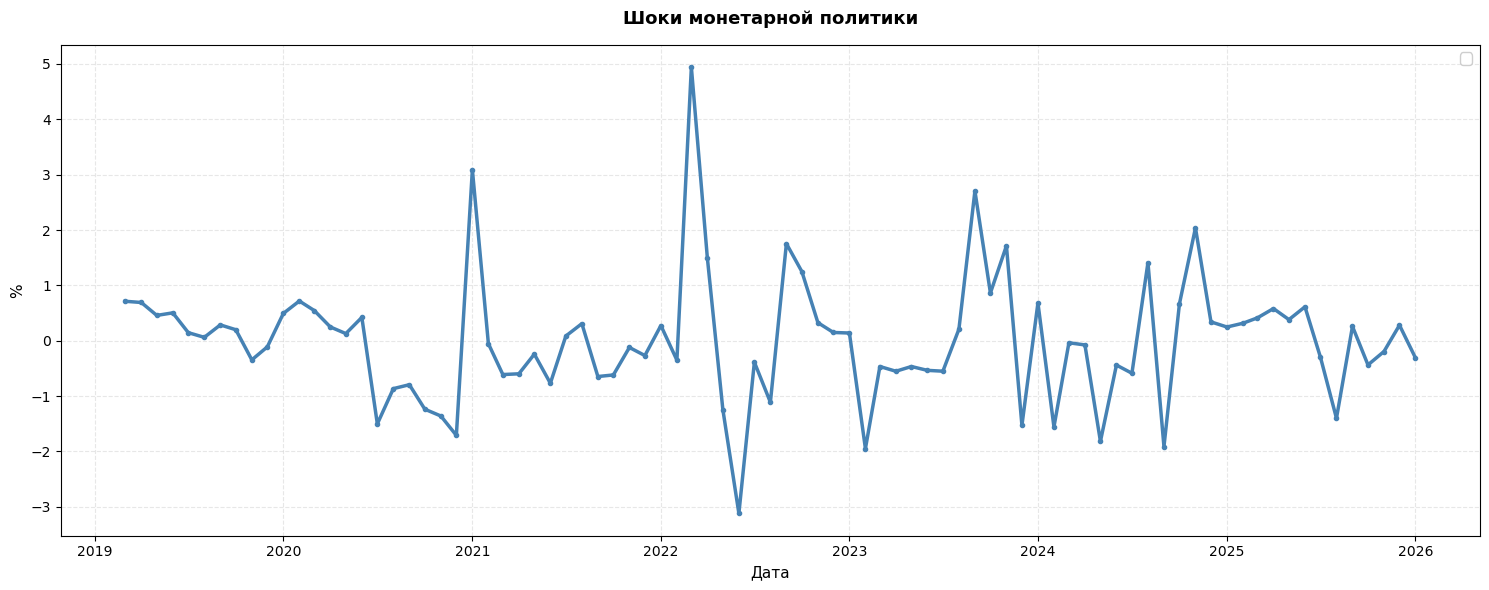


ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ШОКИ МОНЕТАРНОЙ ПОЛИТИКИ
           Mon_Shock
Среднее    -0.000000
Медиана     0.061654
Ст. откл.   1.150131
Мин.       -3.118180
Макс.       4.941478


In [50]:
###############################
# ВЫДЕЛЕНИЕ ШОКОВ МОНЕТАРНОЙ ПОЛИТИКИ
###############################
df_taylor['Taylor_Predicted'] = best_model.fittedvalues     #!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
df_taylor['Mon_Shock'] = best_model.resid    #!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

print("\n" + "="*60)
print("Визуализация шоков монетарной политики")
print("="*60)

fig, ax1 = plt.subplots(figsize=(15, 6))
ax1.plot(df_taylor['Date'], df_taylor['Mon_Shock'], 
         linewidth=2.5, color='steelblue', linestyle='-', marker='o', markersize=3)
ax1.set_title('Шоки монетарной политики', 
              fontsize=13, fontweight='bold', pad=15)
ax1.legend(loc='best', fontsize=11, framealpha=0.95)
ax1.grid(alpha=0.3, linestyle='--')
ax1.set_ylabel('%', fontsize=11)
ax1.set_xlabel('Дата', fontsize=11)
ax1.tick_params(axis='both', labelsize=10)
plt.tight_layout()
plt.show()

###############################
# ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ
###############################
shock_series = df_taylor['Mon_Shock'].dropna()

desc_stats = {
    'Среднее': shock_series.mean(),
    'Медиана': shock_series.median(),
    'Ст. откл.': shock_series.std(),
    'Мин.': shock_series.min(),
    'Макс.': shock_series.max()
}

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ШОКИ МОНЕТАРНОЙ ПОЛИТИКИ")
print("="*60)

desc_df = pd.DataFrame(desc_stats, index=['Mon_Shock']).T
print(desc_df.round(6).to_string())

In [51]:
###############################
    #Тест на стационарность для шоков монетарной политики
###############################
variables_to_test = ['Mon_Shock']

df_test = df_taylor[variables_to_test]

stationarity_results = []
for var in variables_to_test:
    result = stationarity_tests(df_taylor[var], var)
    stationarity_results.append(result)

stationarity_df = pd.DataFrame(stationarity_results)
print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ТЕСТОВ ДЛЯ ШОКОВ")
print("="*60)
print(stationarity_df.to_string())


РЕЗУЛЬТАТЫ ТЕСТОВ ДЛЯ ШОКОВ
    Variable  ADF_Statistic   ADF_p_value  ADF_Critical_1%  ADF_Critical_5%  ADF_Critical_10%  ADF_Stationary  KPSS_Statistic  KPSS_p_value  KPSS_Critical_1%  KPSS_Critical_5%  KPSS_Critical_10%  KPSS_Stationary  DF_GLS_Statistic  DF_GLS_p_value  DF_GLS_Critical_1%  DF_GLS_Critical_5%  DF_GLS_Critical_10%  DF_GLS_Stationary
0  Mon_Shock      -7.851315  5.591400e-12        -3.512738         -2.89749         -2.585949            True        0.037001           0.1             0.739             0.463              0.347             True         -7.139426    5.130041e-11            -2.79457           -2.173927            -1.862896               True


In [52]:
##############################
# Тест Фридмана на сезонность
##############################
variables_for_analysis = [
    ('Mon_Shock', 'Шоки монетарной политики')]
friedman_results = []

for var_col, var_name in variables_for_analysis:
    if var_col in df_taylor.columns:
        result = friedman_seasonality_test(df_taylor, date_col='Date', 
                                          value_col=var_col, 
                                          test_name=var_name)
        if result:
            friedman_results.append(result)

# Сохраняем результаты Фридмана
friedman_summary = pd.DataFrame([
    {
        'Variable': r['variable'],
        'Chi_Squared': r['chi_squared'],
        'P_Value': r['p_value'],
        'Has_Seasonality': r['has_seasonality'],
        'N_Years': r['n_years'],
        'N_Months': r['n_months']
    } 
    for r in friedman_results
])

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ТЕСТОВ ФРИДМАНА")
print("="*80)
print(friedman_summary.to_string(index=False))


РЕЗУЛЬТАТЫ ТЕСТОВ ФРИДМАНА
                Variable  Chi_Squared  P_Value  Has_Seasonality  N_Years  N_Months
Шоки монетарной политики      8.74359 0.645547            False        6        12


In [53]:
###############################
# Тест Льюинга-Бокса для остатков
###############################


ljungbox_results = []
problematic_series = []

# Выполняем тест

result = optimized_ljung_box_test(df_taylor['Mon_Shock'], 'Mon_Shock', 'Исходный')

if result:
    ljungbox_results.append(result)

# === ВЫВОД РЕЗУЛЬТАТОВ ===

print("\n" + "="*70)
print("РЕЗУЛЬТАТЫ ТЕСТА ЛЬЮИНГА-БОКСА")
print("="*70)

if ljungbox_results:
    for i, result in enumerate(ljungbox_results, 1):
        print(f"\n{i}. {result['name']}")
        print(f"   Тип данных: {result['source_type']}")
        print(f"   Наблюдения: {result['n_obs']}")
        print(f"   Тестовые лаги: {result['test_lags']}")
        print(f"   Ljung-Box статистика: {result['lb_statistic']:.3f}")
        print(f"   P-значение: {result['p_value']:.6f}")
        
        if result['is_white_noise']:
            print(f"   ✓ ОСТАТКИ БЕЗ АВТОКОРРЕЛЯЦИИ (p > 0.05)")
        else:
            print(f"   ✗ ОБНАРУЖЕНА АВТОКОРРЕЛЯЦИЯ (p < 0.05)")
            problematic_series.append(result)
        
        # Ключевые лаги
        print(f"   Ключевые лаги:")
        for key_res in result['key_lags_results']:
            sig_mark = "✓" if key_res['pvalue'] > 0.05 else "✗"
            print(f"     Лаг {key_res['lag']:2d}: p={key_res['pvalue']:.6f} {sig_mark}")

# === СВОДНАЯ ТАБЛИЦА ===

if ljungbox_results:
    print("\n" + "="*70)
    print("СВОДНАЯ ТАБЛИЦА")
    print("="*70)
    
    summary_data = []
    for result in ljungbox_results:
        # Подсчитываем количество значимых лагов из ключевых
        sig_lags = sum(1 for res in result['key_lags_results'] if res['pvalue'] < 0.05)
        total_lags = len(result['key_lags_results'])
        
        # Определяем статус
        if result['is_white_noise']:
            status = "✓ OK"
        elif sig_lags <= 2:
            status = "⚠ Приемлемо"
        else:
            status = "✗ Проблема"
        
        summary_data.append({
            'Переменная': result['name'],
            'Тип данных': result['source_type'],
            'N': result['n_obs'],
            'P-значение': f"{result['p_value']:.6f}",
            'Значимые лаги': f"{sig_lags}/{total_lags}",
            'Статус': status
        })
    
    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))


РЕЗУЛЬТАТЫ ТЕСТА ЛЬЮИНГА-БОКСА

1. Mon_Shock
   Тип данных: Исходный
   Наблюдения: 83
   Тестовые лаги: 19
   Ljung-Box статистика: 24.807
   P-значение: 0.166987
   ✓ ОСТАТКИ БЕЗ АВТОКОРРЕЛЯЦИИ (p > 0.05)
   Ключевые лаги:
     Лаг  1: p=0.222964 ✓
     Лаг  3: p=0.142592 ✓
     Лаг  6: p=0.156136 ✓
     Лаг 12: p=0.611672 ✓

СВОДНАЯ ТАБЛИЦА
Переменная Тип данных  N P-значение Значимые лаги Статус
 Mon_Shock   Исходный 83   0.166987           0/4   ✓ OK



ЯДЕРНАЯ ОЦЕНКА ПЛОТНОСТИ РАСПРЕДЕЛЕНИЯ ОСТАТКОВ МОДЕЛИ


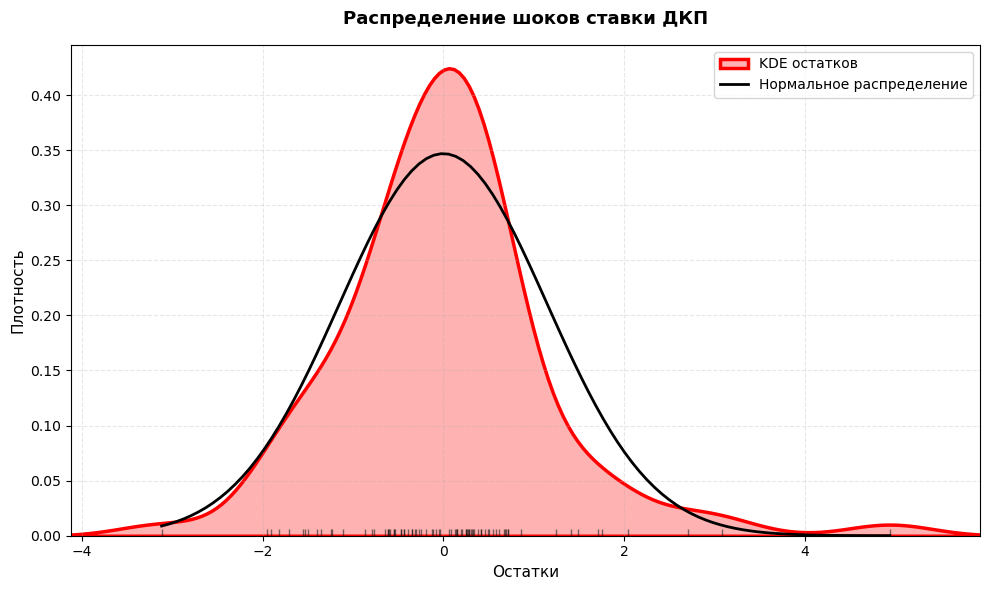


Параметры распределения:
  Среднее остатков: -0.000000
  Стд. отклонение: 1.150131
  Асимметрия (Skewness): 0.9677
  Эксцесс (Kurtosis): 3.8018
  N наблюдений: 83


In [54]:
###############################
# Ядерная оценка плотности распределения остатков
###############################
from scipy import stats
# Получаем остатки из лучшей модели
residuals = best_model.resid

print("\n" + "="*80)
print("ЯДЕРНАЯ ОЦЕНКА ПЛОТНОСТИ РАСПРЕДЕЛЕНИЯ ОСТАТКОВ МОДЕЛИ")
print("="*80)

fig, ax = plt.subplots(figsize=(10, 6))

# KDE + гистограмма
sns.kdeplot(residuals, fill=True, color='red', alpha=0.3, linewidth=2.5, label='KDE остатков')

# Нормальное распределение для сравнения
mu = residuals.mean()
sigma = residuals.std()
x = np.linspace(residuals.min(), residuals.max(), 100)
normal_dist = stats.norm.pdf(x, mu, sigma)
ax.plot(x, normal_dist, 'k-', linewidth=2, label='Нормальное распределение')

# Галочки остатков внизу оси X
for residual in residuals:
    ax.plot(residual, 0, '|', color='black', markersize=10, alpha=0.5)

ax.set_title('Распределение шоков ставки ДКП', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Остатки', fontsize=11)
ax.set_ylabel('Плотность', fontsize=11)
ax.legend(loc='best', fontsize=10)
ax.grid(alpha=0.3, linestyle='--')
ax.set_xlim(residuals.min() - 1, residuals.max() + 1)

plt.tight_layout()
plt.show()

print(f"\nПараметры распределения:")
print(f"  Среднее остатков: {residuals.mean():.6f}")
print(f"  Стд. отклонение: {residuals.std():.6f}")
print(f"  Асимметрия (Skewness): {stats.skew(residuals):.4f}")
print(f"  Эксцесс (Kurtosis): {stats.kurtosis(residuals):.4f}")
print(f"  N наблюдений: {len(residuals)}")


In [55]:
mon_shock_dataset = df_taylor[['Date', 'Mon_Shock']].copy()
pickle_filename = 'mon_shock_dataset.pkl'
with open(pickle_filename, 'wb') as f:
    pickle.dump(mon_shock_dataset, f)

In [56]:
df_taylor['Taylor_Predicted'] = model1.fittedvalues


Сравнение модельных предсказаний с ключевой ставкой

Корреляция ключевой ставки и предсказаний модели: 0.9736


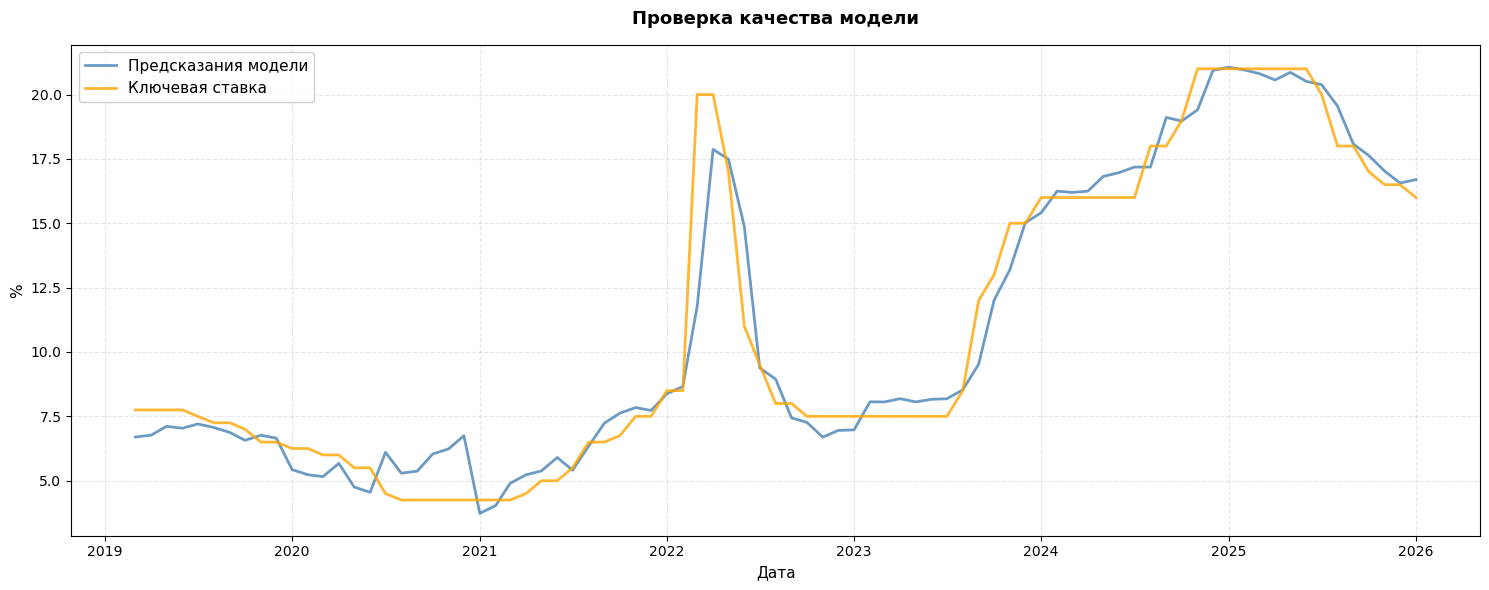

In [57]:
print("\n" + "="*60)
print("Сравнение модельных предсказаний с ключевой ставкой")
print("="*60)

corr_key_rate = df_taylor['Taylor_Predicted'].corr(df_taylor['Key_Rate'])
print(f"\nКорреляция ключевой ставки и предсказаний модели: {corr_key_rate:.4f}")

fig, ax1 = plt.subplots(figsize=(15, 6))

# График: Компоненты и итоговый индекс
ax1.plot(df_taylor['Date'], df_taylor['Taylor_Predicted'], 
         label='Предсказания модели', linewidth=2, alpha=0.8, color='steelblue')
ax1.plot(df_taylor['Date'], df_taylor['Key_Rate'], 
         label='Ключевая ставка', linewidth=2, alpha=0.8, color='orange')

ax1.set_title('Проверка качества модели', 
              fontsize=13, fontweight='bold', pad=15)
ax1.legend(loc='best', fontsize=11, framealpha=0.95)
ax1.grid(alpha=0.3, linestyle='--')
ax1.set_ylabel('%', fontsize=11)
ax1.set_xlabel('Дата', fontsize=11)
ax1.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()